# Config

In [1]:
Proj_path = '/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/FG_2026_Projections'

In [2]:
League_path = '/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/Imaginary_Hammers'

In [3]:
import sys
sys.path.append('../')

In [4]:
Latest_Proj = {
    'Hitter':'Jan23_2026',
    'Pitcher':'Jan23_2026'
}

In [5]:
SCP_Calc_date = 'Jan25_2026'

In [6]:
import pandas as pd
Hitter_Projections_df = pd.read_csv(f"{Proj_path}/my_Hitter_Proj_{Latest_Proj['Hitter']}.csv")
Pitcher_Projections_df = pd.read_csv(f"{Proj_path}/my_Pitcher_Proj_{Latest_Proj['Pitcher']}.csv")
Pitcher_Projections_df['K'] = Pitcher_Projections_df['SO']

#Filter Pitchers
Pitcher_Projections_df = Pitcher_Projections_df[Pitcher_Projections_df['IP'] > 10.]

In [7]:
from Stat_modules import OBP,SLG,HR9,ERA,WHIP,TB
Hitter_Projections_df['OBP'] = OBP(Hitter_Projections_df['H'],Hitter_Projections_df['BB'],Hitter_Projections_df['HBP'],Hitter_Projections_df['SF'],Hitter_Projections_df['AB'])
Hitter_Projections_df['TB'] = TB(Hitter_Projections_df['1B'],Hitter_Projections_df['2B'],Hitter_Projections_df['3B'],Hitter_Projections_df['HR'])
Hitter_Projections_df['SLG'] = SLG(Hitter_Projections_df['TB'],Hitter_Projections_df['AB'])
Pitcher_Projections_df['HR9'] = HR9(Pitcher_Projections_df['HR'],Pitcher_Projections_df['IP'])
Pitcher_Projections_df['ERA'] = ERA(Pitcher_Projections_df['ER'],Pitcher_Projections_df['IP'])
Pitcher_Projections_df['WHIP'] = WHIP(Pitcher_Projections_df['BB'],Pitcher_Projections_df['H'],Pitcher_Projections_df['IP'])

In [8]:
#Jan23 2025 Roster totals
Replacement_Level = {
    'C':24,
    '1B':25,
    '2B':27,
    'SS':44,
    '3B':19,
    'OF':89,
    'DH':233,
    'SP':150,
    'RP':65,
    'P':215
}
Replacement_window = {
    'C':5,
    '1B':5,
    '2B':5,
    'SS':5,
    '3B':5,
    'OF':5,
    'DH':5,
    'SP':5,
    'RP':5,
    'P':5
}
Replacement_rank_stat = 'WAR'
Hitting_Pos = [
    'C',
    '1B',
    '2B',
    'SS',
    '3B',
    'OF',
    'DH'
]
Pitching_Pos = [
    'SP',
    'RP',
    'P'
]

All_Pos = Hitting_Pos + Pitching_Pos

In [9]:
#Scoring Categories
Count_Scoring_Categories_Batting = [
    'R',
    'HR'
]
Rate_Scoring_Categories_Batting = [
    'OBP',
    'SLG'
]
Count_Scoring_Categories_Pitching = [
    'K'
]
Rate_Scoring_Categories_Pitching = [
    "HR9",
    "ERA",
    "WHIP"
]
Num_teams = 12.
Team_budget = 400.
Hitter_sal_split = 0.53
League_budget = Team_budget*Num_teams
Hitter_budget = League_budget*Hitter_sal_split
Pitcher_budget = League_budget*(1.-Hitter_sal_split)
Scoring_Categories_Batting = Count_Scoring_Categories_Batting + Rate_Scoring_Categories_Batting
Scoring_Categories_Pitching = Count_Scoring_Categories_Pitching + Rate_Scoring_Categories_Pitching
Scoring_Categories = Scoring_Categories_Batting + Scoring_Categories_Pitching

In [10]:
Hitter_budget

2544.0

In [11]:
Player_id_cols = [
    'PlayerId','MLBAMID','POS','Name', 'Team','NameASCII'
]
Hitter_Count_Stats = [
    'G','PA','AB','H','1B','2B','3B','HR','R','RBI','BB','HBP','SF','WAR','ADP'
]
Pitcher_Count_Stats = [
    'W', 'L', 'QS', 'G', 'GS', 'SV', 'HLD', 'IP', 'TBF', 'H', 'R', 'ER', 'HR', 'BB', 'HBP', 'K','WAR','ADP'
]

In [12]:
import json
with open(League_path+'/SGP_Denom_dict.json','r') as f:
    SGP_Denom = json.load(f)

# Replacement Level & Playable Average Stats

C
1B
2B
SS
3B
OF
DH


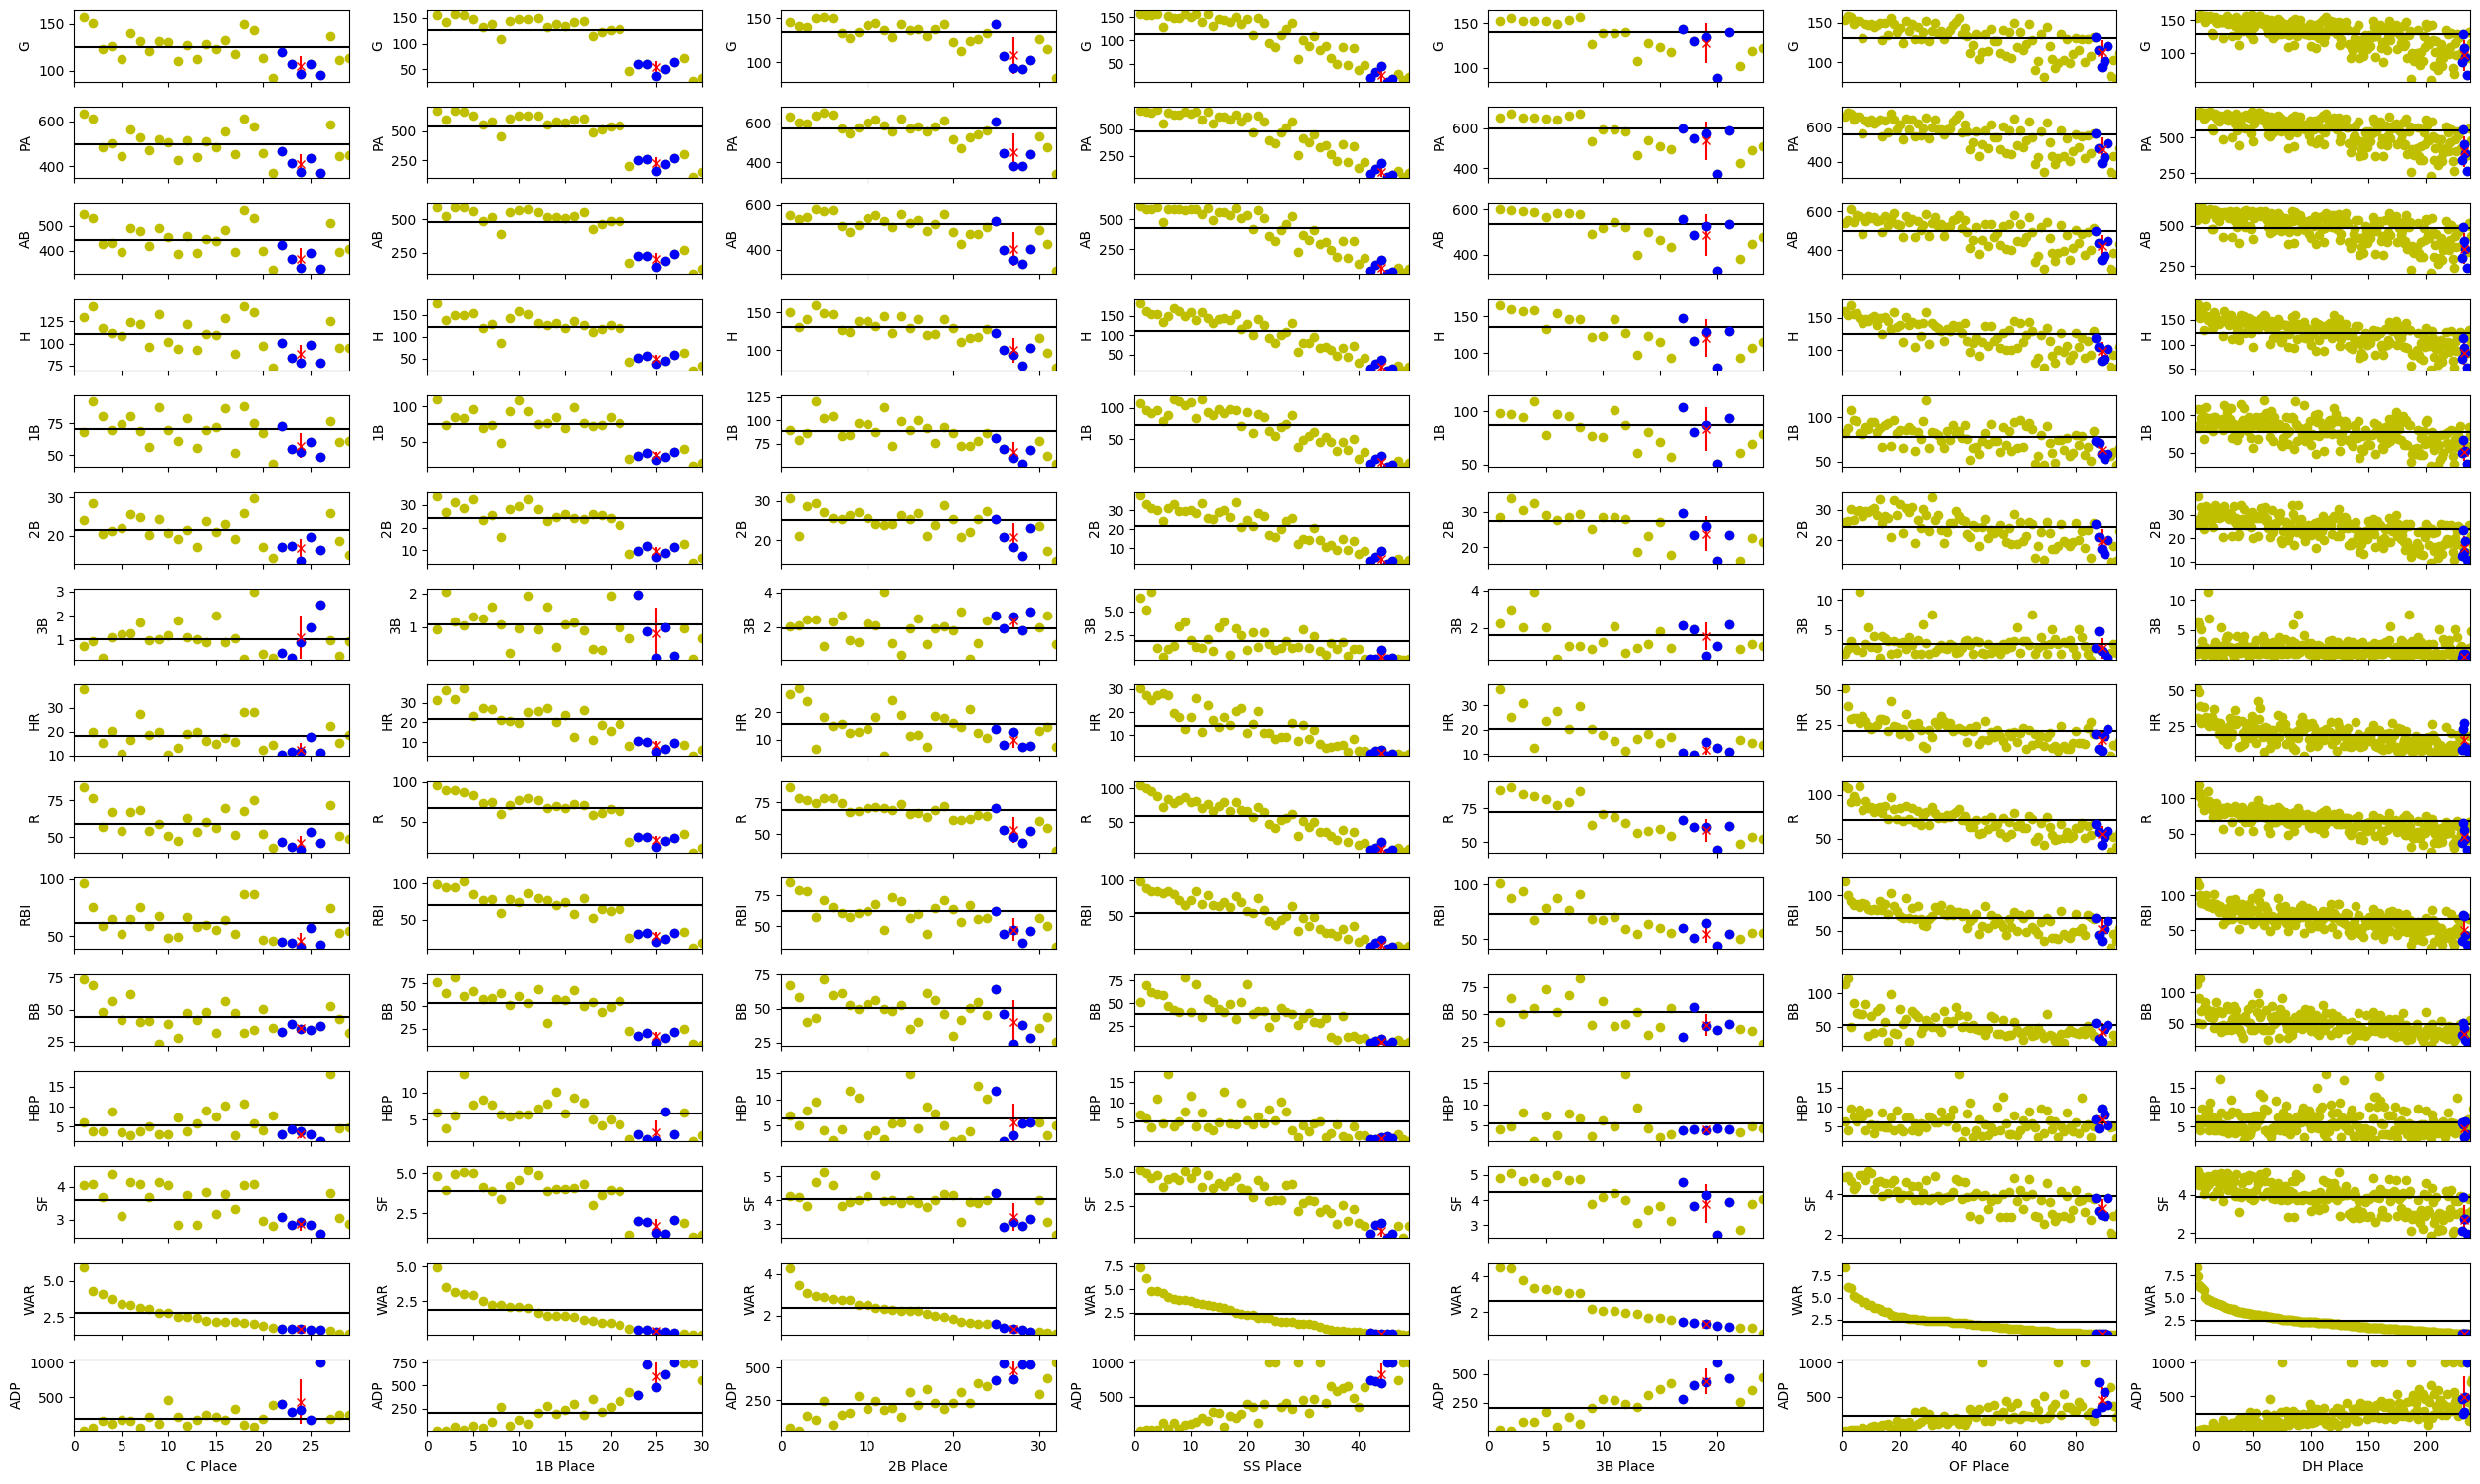

In [13]:
import matplotlib.pyplot as plt
import numpy as np

Hitting_Replacement_Stats_df = pd.DataFrame()
Hitting_Average_Stats_df = pd.DataFrame()

fig, axs = plt.subplots(len(Hitter_Count_Stats),len(Hitting_Pos),figsize=(25,15),sharex='col')
pos_idx = 0
for pos,repl_level_mid in Replacement_Level.items():
    if pos in Pitching_Pos:
        continue
    This_Pos_df = Hitter_Projections_df[Hitter_Projections_df['POS'].apply(lambda x : f"\'{pos}\'" in x.strip('[]').split(','))]
    if pos == 'DH':
        This_Pos_df = Hitter_Projections_df
    print(pos)
    This_Pos_df['Pos Place'] = This_Pos_df[Replacement_rank_stat].rank(method="dense", ascending=False)
    col_idx = 0
    x_max = repl_level_mid+Replacement_window[pos]


    for col in Hitter_Count_Stats:
        this_axis = axs[col_idx][pos_idx]
        this_axis.plot(This_Pos_df['Pos Place'],This_Pos_df[col], 'yo')

        Replacement_this_Pos_df = This_Pos_df[(This_Pos_df['Pos Place'] >= repl_level_mid-(Replacement_window[pos]/2)) \
                                              & (This_Pos_df['Pos Place'] <= repl_level_mid+(Replacement_window[pos]/2))
                                            ]
        mean = Replacement_this_Pos_df[col].mean()
        std = Replacement_this_Pos_df[col].std()
        Hitting_Replacement_Stats_df = pd.concat([
            Hitting_Replacement_Stats_df,
            pd.DataFrame([{
                'POS':pos,
                'Stat':f'{col}_repl',
                'mean':mean
            }])
        ])
        this_axis.errorbar(x=[Replacement_this_Pos_df[Replacement_this_Pos_df['Pos Place'] == repl_level_mid]['Pos Place']], y=[mean],yerr=[std], fmt='x',color='r')

        Playable_this_Pos_df = This_Pos_df[(This_Pos_df['Pos Place'] <= repl_level_mid)]
        coef = np.polyfit(Playable_this_Pos_df['Pos Place'],Playable_this_Pos_df[col],1)
        poly1d_fn = np.poly1d(coef) 
        Hitting_Average_Stats_df = pd.concat([
            Hitting_Average_Stats_df,
            pd.DataFrame([{
                'POS':pos,
                'Stat':f'{col}_avg',
                'mean':poly1d_fn(repl_level_mid/2)
            }])
        ])
        this_axis.axhline(poly1d_fn(repl_level_mid/2),color='k')

        this_axis.plot(Replacement_this_Pos_df['Pos Place'],Replacement_this_Pos_df[col], 'bo')
        

        this_axis.set_ylabel(col)
        ymin = 0.95*This_Pos_df[This_Pos_df['Pos Place'] <= x_max][col].min()
        ymax = 1.05*This_Pos_df[This_Pos_df['Pos Place'] <= x_max][col].max()
        this_axis.set_ylim([ymin,ymax])
        col_idx+=1
    pos_idx+=1
    this_axis.set_xlim([0,x_max])
    this_axis.set_xlabel(f'{pos} Place')
plt.tight_layout()

In [14]:
Hitting_Replacement_Stats_df

,POS,Stat,mean
0,C,G_repl,105.117627
0,C,PA_repl,411.733097
0,C,AB_repl,368.688800
0,C,H_repl,87.953671
0,C,1B_repl,57.605329
...,...,...,...
0,DH,BB_repl,34.054695
0,DH,HBP_repl,4.584483
0,DH,SF_repl,2.689076
0,DH,WAR_repl,0.923805


In [15]:
Hitting_Average_Stats_df

,POS,Stat,mean
0,C,G_avg,125.470307
0,C,PA_avg,499.245187
0,C,AB_avg,444.684201
0,C,H_avg,110.849961
0,C,1B_avg,70.322587
...,...,...,...
0,DH,BB_avg,49.382660
0,DH,HBP_avg,5.940868
0,DH,SF_avg,3.864399
0,DH,WAR_avg,2.372121


SP
RP
P


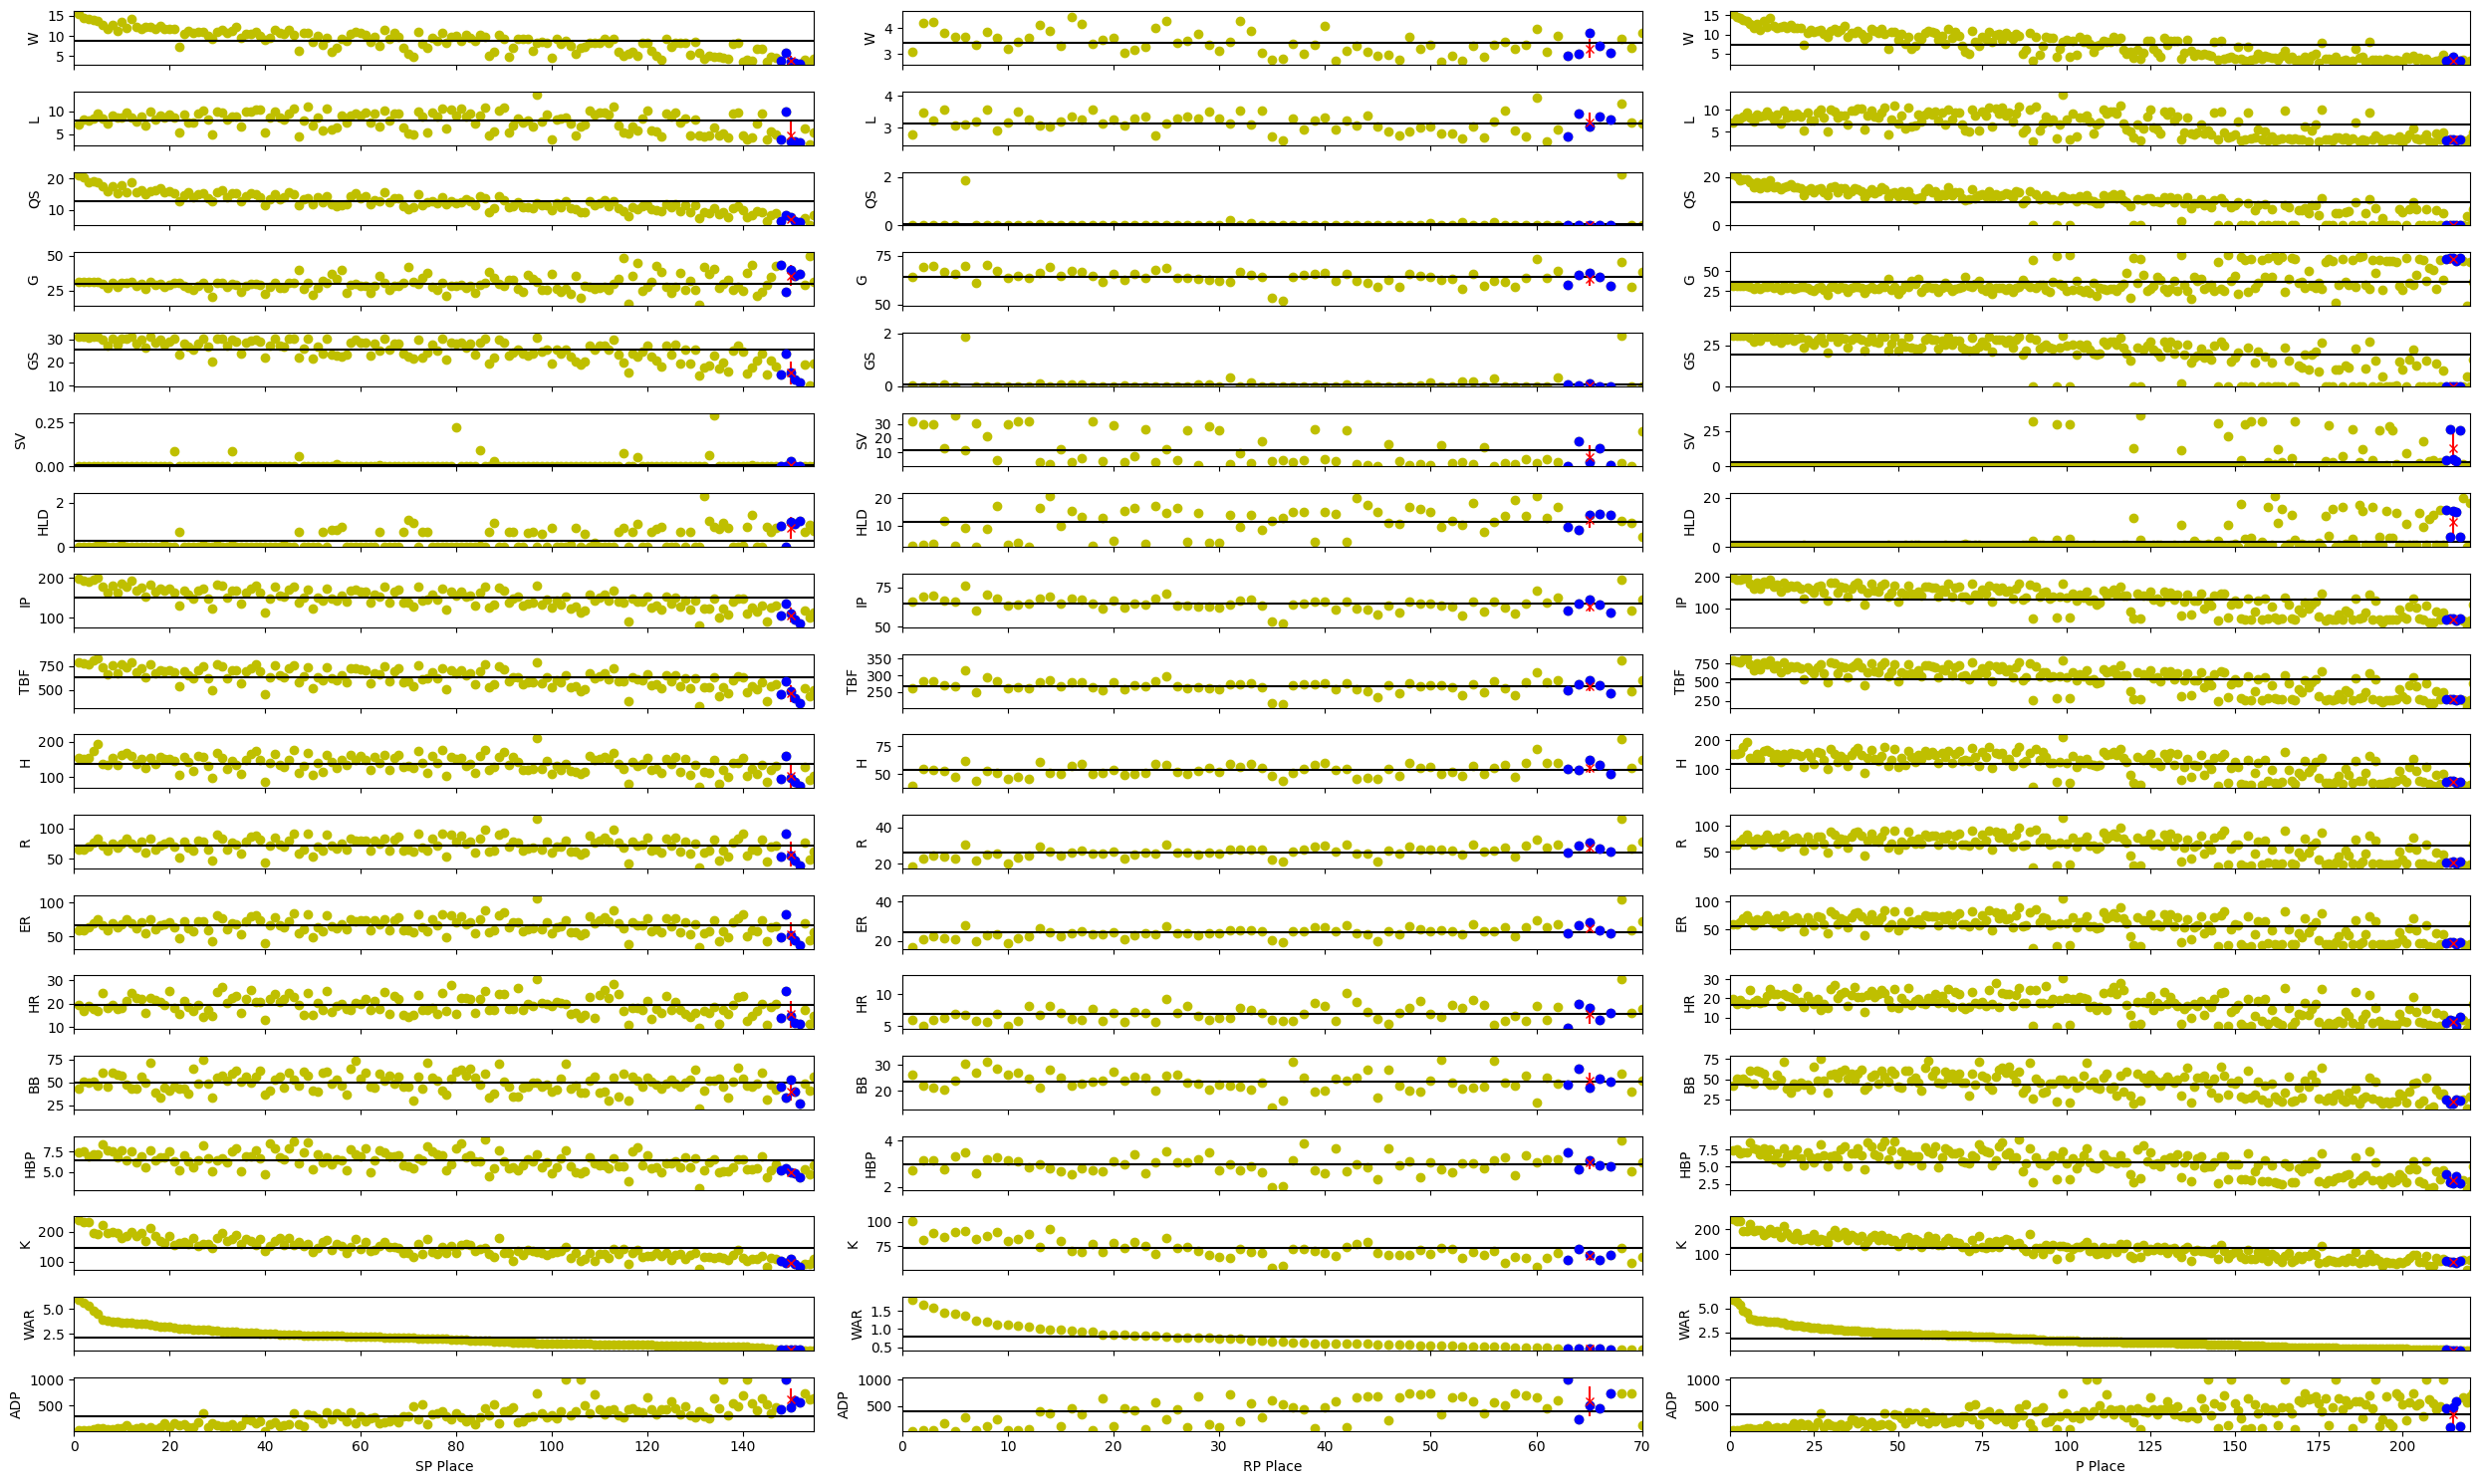

In [16]:
import matplotlib.pyplot as plt
import numpy as np

Pitching_Replacement_Stats_df = pd.DataFrame()
Pitching_Average_Stats_df = pd.DataFrame()

fig, axs = plt.subplots(len(Pitcher_Count_Stats),len(Pitching_Pos),figsize=(25,15),sharex='col')
pos_idx = 0
for pos,repl_level_mid in Replacement_Level.items():
    if pos in Hitting_Pos:
        continue
    This_Pos_df = Pitcher_Projections_df[Pitcher_Projections_df['POS'].apply(lambda x : f"\'{pos}\'" in x.strip('[]').split(','))]
    if pos == 'P':
        This_Pos_df = Pitcher_Projections_df
    print(pos)
    This_Pos_df['Pos Place'] = This_Pos_df[Replacement_rank_stat].rank(method="dense", ascending=False)
    col_idx = 0
    x_max = repl_level_mid+Replacement_window[pos]


    for col in Pitcher_Count_Stats:
        this_axis = axs[col_idx][pos_idx]
        this_axis.plot(This_Pos_df['Pos Place'],This_Pos_df[col], 'yo')

        Replacement_this_Pos_df = This_Pos_df[(This_Pos_df['Pos Place'] >= repl_level_mid-(Replacement_window[pos]/2)) \
                                              & (This_Pos_df['Pos Place'] <= repl_level_mid+(Replacement_window[pos]/2))
                                            ]
        mean = Replacement_this_Pos_df[col].mean()
        std = Replacement_this_Pos_df[col].std()
        Pitching_Replacement_Stats_df = pd.concat([
            Pitching_Replacement_Stats_df,
            pd.DataFrame([{
                'POS':pos,
                'Stat':f'{col}_repl',
                'mean':mean,
                'std':std
            }])
        ])
        this_axis.errorbar(x=[Replacement_this_Pos_df[Replacement_this_Pos_df['Pos Place'] == repl_level_mid]['Pos Place']], y=[mean],yerr=[std], fmt='x',color='r')

        Playable_this_Pos_df = This_Pos_df[(This_Pos_df['Pos Place'] <= repl_level_mid)]
        coef = np.polyfit(Playable_this_Pos_df['Pos Place'],Playable_this_Pos_df[col],1)
        poly1d_fn = np.poly1d(coef) 
        Pitching_Average_Stats_df = pd.concat([
            Pitching_Average_Stats_df,
            pd.DataFrame([{
                'POS':pos,
                'Stat':f'{col}_avg',
                'mean':poly1d_fn(repl_level_mid/2)
            }])
        ])
        this_axis.axhline(poly1d_fn(repl_level_mid/2),color='k')

        this_axis.plot(Replacement_this_Pos_df['Pos Place'],Replacement_this_Pos_df[col], 'bo')
        

        this_axis.set_ylabel(col)
        ymin = 0.95*This_Pos_df[This_Pos_df['Pos Place'] <= x_max][col].min()
        ymax = 1.05*This_Pos_df[This_Pos_df['Pos Place'] <= x_max][col].max()
        this_axis.set_ylim([ymin,ymax])
        col_idx+=1
    pos_idx+=1
    this_axis.set_xlim([0,x_max])
    this_axis.set_xlabel(f'{pos} Place')
plt.tight_layout()

In [17]:
Pitching_Replacement_Stats_df.head()

,POS,Stat,mean,std
0,SP,W_repl,3.898110,1.083110
0,SP,L_repl,4.759955,2.913881
0,SP,QS_repl,7.016453,0.928755
0,SP,G_repl,35.827440,7.379325
0,SP,GS_repl,15.541649,4.880582


# Calc Raw SGP

In [18]:
Rate_Scoring_Categories_Batting

['OBP', 'SLG']

In [19]:
Rate_Scoring_Categories_Pitching

['HR9', 'ERA', 'WHIP']

In [20]:
SGP_Denom

{'R': 25.28251748251743,
 'HR': 11.508403361344515,
 'OBP': 0.002503279720279701,
 'SLG': 0.00528697202797202,
 'K': 47.5227326545109,
 'HR9': -0.026016417074877514,
 'ERA': -0.08937283374192077,
 'WHIP': -0.017438135920127117}

In [21]:
for stat in Count_Scoring_Categories_Batting:
    Hitter_Projections_df[f'{stat}_SGP_raw'] = Hitter_Projections_df[stat]/SGP_Denom[stat]

In [22]:
for stat in Count_Scoring_Categories_Pitching:
    Pitcher_Projections_df[f'{stat}_SGP_raw'] = Pitcher_Projections_df[stat]/SGP_Denom[stat]

In [23]:
Hitting_Replacement_Stats_df.pivot_table('mean','POS','Stat').reset_index()

Stat,POS,1B_repl,2B_repl,3B_repl,AB_repl,ADP_repl,BB_repl,G_repl,HBP_repl,HR_repl,H_repl,PA_repl,RBI_repl,R_repl,SF_repl,WAR_repl
0,1B,30.252780,9.842962,0.817708,205.750330,596.141998,16.977879,54.421330,2.672852,8.315246,49.348708,227.758930,27.683857,26.621135,1.690244,0.347463
1,2B,66.755112,20.726440,2.396470,403.174800,479.063995,39.939864,107.595648,5.502096,10.037695,99.555704,453.698160,46.978072,53.466184,3.287539,1.375167
2,3B,83.314720,23.798592,1.575662,486.776720,437.371997,40.234752,127.349200,4.098032,11.708834,120.517688,537.183200,54.823168,58.908040,3.855494,1.330681
3,C,57.605329,16.847775,1.123042,368.688800,436.313998,35.697647,105.117627,3.218982,12.411811,87.953671,411.733097,46.061157,46.176634,2.849641,1.681751
4,DH,50.579605,15.991245,0.500085,358.067257,493.096002,34.054695,96.957921,4.584483,15.569905,82.640845,400.247589,49.930494,45.259478,2.689076,0.923805
5,OF,62.960306,19.781277,1.920478,419.726309,451.348004,42.488990,112.952883,6.868171,14.393717,99.055790,474.255543,52.807911,55.803808,3.342437,0.874515
6,SS,13.423092,4.390418,0.264605,91.201392,833.593994,7.412391,24.797544,1.124192,2.419746,20.257856,100.845152,9.849939,11.161982,0.615311,0.227796


In [24]:
Hitting_Average_Stats_df.pivot_table('mean','POS','Stat')

Stat,1B_avg,2B_avg,3B_avg,AB_avg,ADP_avg,BB_avg,G_avg,HBP_avg,HR_avg,H_avg,PA_avg,RBI_avg,R_avg,SF_avg,WAR_avg
POS,,,,,,,,,,,,,,,
1B,74.705758,24.045682,1.086896,476.271416,211.003965,52.759601,126.447242,6.066374,21.853930,121.588614,539.558731,70.511945,67.328509,3.866101,1.868731
2B,88.544466,25.192892,1.931231,512.373324,224.757838,50.620911,134.702976,6.292318,15.585074,131.020232,575.036588,62.614007,69.292695,4.038735,2.344330
3B,86.924775,27.408410,1.626930,536.501090,199.903237,51.675616,140.423448,5.526622,20.079362,136.185233,599.252313,72.536074,72.334915,4.332038,2.608250
C,70.322587,21.456572,1.046951,444.684201,192.695673,44.556166,125.470307,5.421169,18.035441,110.849961,499.245187,61.662210,59.104478,3.593827,2.808856
DH,77.962077,24.093544,1.983372,486.671758,244.648528,49.382660,129.466758,5.940868,18.803753,122.772038,547.077227,65.651568,67.807350,3.864399,2.372121
OF,77.554050,24.407575,2.619662,495.891163,221.630584,52.076397,131.102617,5.970597,20.404587,124.938964,559.034170,68.446367,71.681769,3.926987,2.293606
SS,71.693932,21.937766,1.927477,432.194462,361.075850,38.688478,113.315223,5.304327,14.083338,109.576816,481.151047,54.376337,58.787500,3.372048,2.375042


In [25]:
rest_of_roster_df = Hitting_Average_Stats_df[Hitting_Average_Stats_df['POS'] == 'DH']
full_roster_df = Hitting_Average_Stats_df[Hitting_Average_Stats_df['POS'] == 'DH']

In [26]:
rest_of_roster_df['rest_of_roster_count'] = (Replacement_Level['DH']/Num_teams)-1.
full_roster_df['full_roster_count'] = (Replacement_Level['DH']/Num_teams)

In [27]:
rest_of_roster_df['rest_of_roster'] = rest_of_roster_df['rest_of_roster_count']*rest_of_roster_df['mean']
full_roster_df['full_roster'] = full_roster_df['full_roster_count']*full_roster_df['mean']

In [28]:
rest_of_roster_stats = rest_of_roster_df.pivot_table('rest_of_roster','POS','Stat')
full_roster_stats = full_roster_df.pivot_table('full_roster','POS','Stat')

In [29]:
rest_of_roster_stats['H_avg'].values[0]

np.float64(2261.0516958874814)

In [30]:
full_roster_stats['H_avg'].values[0]

np.float64(2383.823733673227)

In [31]:
full_roster_OBP = OBP(
        full_roster_stats['H_avg'].values[0],
        full_roster_stats['BB_avg'].values[0],
        full_roster_stats['HBP_avg'].values[0],
        full_roster_stats['SF_avg'].values[0],
        full_roster_stats['AB_avg'].values[0]
    ) 

In [32]:
Hitter_Projections_df['OBP_SGP_raw'] = (
    OBP(
        (Hitter_Projections_df['H']+rest_of_roster_stats['H_avg'].values[0]),
        (Hitter_Projections_df['BB']+rest_of_roster_stats['BB_avg'].values[0]),
        (Hitter_Projections_df['HBP']+rest_of_roster_stats['HBP_avg'].values[0]),
        (Hitter_Projections_df['SF']+rest_of_roster_stats['SF_avg'].values[0]),
        (Hitter_Projections_df['AB']+rest_of_roster_stats['AB_avg'].values[0])) \
    - full_roster_OBP) / SGP_Denom['OBP']

In [33]:
rest_of_roster_TB = TB(
    rest_of_roster_stats['1B_avg'].values[0],
    rest_of_roster_stats['2B_avg'].values[0],
    rest_of_roster_stats['3B_avg'].values[0],
    rest_of_roster_stats['HR_avg'].values[0])
full_roster_TB = TB(
    full_roster_stats['1B_avg'].values[0],
    full_roster_stats['2B_avg'].values[0],
    full_roster_stats['3B_avg'].values[0],
    full_roster_stats['HR_avg'].values[0])
full_roster_SLG = SLG(full_roster_TB,full_roster_stats['AB_avg'].values[0])
Hitter_Projections_df['SLG_SGP_raw'] = (
    SLG(
        (Hitter_Projections_df['TB']+rest_of_roster_TB),
        (Hitter_Projections_df['AB']+rest_of_roster_stats['AB_avg'].values[0])) \
    -  full_roster_SLG) / SGP_Denom['SLG']

In [34]:
Hitter_Projections_df['TOTAL_SGP_raw'] = Hitter_Projections_df[[f'{col}_SGP_raw' for col in Scoring_Categories_Batting]].sum(axis=1)

In [35]:
Hitter_Projections_df.sort_values('TOTAL_SGP_raw',ascending=False).head(10)

,PlayerId,MLBAMID,Name,Team,NameASCII,G,PA,AB,H,1B,...,POS,OBP,TB,SLG,Pos Place,R_SGP_raw,HR_SGP_raw,OBP_SGP_raw,SLG_SGP_raw,TOTAL_SGP_raw
59,15640,592450,Aaron Judge,NYY,Aaron Judge,153.025200,662.062400,537.949600,160.618000,82.237120,...,['OF'],0.422946,342.627564,0.636914,1.0,4.347273,4.459256,2.387244,2.258978,13.452751
169,19755,660271,Shohei Ohtani,LAD,Shohei Ohtani,154.564800,675.760000,576.206000,164.762400,82.635640,...,['DH'],0.384457,351.095000,0.609322,3.0,4.683078,4.219974,1.464080,2.094678,12.461810
200,20123,665742,Juan Soto,NYM,Juan Soto,157.975200,684.287600,552.705600,154.576000,88.319000,...,['OF'],0.411102,301.469260,0.545443,4.0,4.246365,3.374845,2.160035,1.312412,11.093658
162,19611,665489,Vladimir Guerrero Jr.,TOR,Vladimir Guerrero Jr.,156.366000,676.026000,588.644400,176.887600,110.617600,...,['1B'],0.382989,306.908984,0.521383,9.0,3.792140,2.728834,1.426143,1.112031,9.059148
70,16478,656941,Kyle Schwarber,PHI,Kyle Schwarber,155.792571,675.800571,564.906857,132.357714,67.557886,...,"['OF', 'DH']",0.352581,282.116570,0.499404,54.0,3.858024,3.685540,0.661525,0.823364,9.028454
117,18401,660670,Ronald Acuña Jr.,ATL,Ronald Acuna Jr.,148.186000,642.174000,545.095200,156.012400,96.978760,...,['OF'],0.386985,277.488072,0.509064,8.0,3.878981,2.621778,1.455366,0.900892,8.857017
375,25764,677951,Bobby Witt Jr.,KCR,Bobby Witt Jr.,156.003600,674.313200,610.947200,182.213600,107.513200,...,['SS'],0.356083,324.242432,0.530721,2.0,4.165962,2.645945,0.748301,1.264189,8.824396
156,19556,670541,Yordan Alvarez,HOU,Yordan Alvarez,130.497143,562.494286,480.731429,142.412571,81.625143,...,"['OF', 'DH']",0.389693,267.197349,0.555814,14.0,3.292278,2.725606,1.342474,1.250069,8.610427
589,35110,701762,Nick Kurtz,ATH,Nick Kurtz,141.979200,598.812800,526.843600,139.304000,74.174000,...,['1B'],0.345695,278.817316,0.529222,34.0,3.546759,3.143063,0.435964,1.084083,8.209870
386,25878,682998,Corbin Carroll,ARI,Corbin Carroll,152.658800,659.492400,575.403200,150.470400,82.360360,...,['OF'],0.347877,283.375760,0.492482,11.0,4.346007,2.321410,0.531248,0.758762,7.957427


<Axes: >

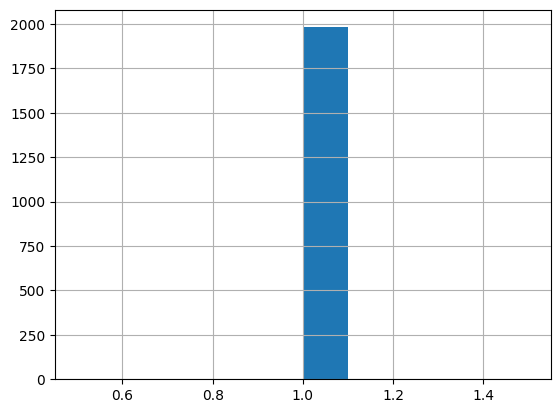

In [36]:
Hitter_Projections_df.PlayerId.value_counts().hist()

In [37]:
rest_of_roster_SP_df = Pitching_Average_Stats_df[Pitching_Average_Stats_df['POS'] == 'SP']
full_roster_SP_df = Pitching_Average_Stats_df[Pitching_Average_Stats_df['POS'] == 'SP']
rest_of_roster_RP_df = Pitching_Average_Stats_df[Pitching_Average_Stats_df['POS'] == 'RP']
full_roster_RP_df = Pitching_Average_Stats_df[Pitching_Average_Stats_df['POS'] == 'RP']
rest_of_roster_P_df = Pitching_Average_Stats_df[Pitching_Average_Stats_df['POS'] == 'P']
full_roster_P_df = Pitching_Average_Stats_df[Pitching_Average_Stats_df['POS'] == 'P']

In [38]:
rest_of_roster_SP_df['rest_of_roster_count'] = (Replacement_Level['SP']/Num_teams)-1.
full_roster_SP_df['full_roster_count'] = (Replacement_Level['SP']/Num_teams)
rest_of_roster_RP_df['rest_of_roster_count'] = (Replacement_Level['RP']/Num_teams)-1.
full_roster_RP_df['full_roster_count'] = (Replacement_Level['RP']/Num_teams)
rest_of_roster_P_df['rest_of_roster_count'] = (Replacement_Level['P']/Num_teams)-1.
full_roster_P_df['full_roster_count'] = (Replacement_Level['P']/Num_teams)

In [39]:
rest_of_roster_SP_df['rest_of_roster'] = rest_of_roster_SP_df['rest_of_roster_count']*rest_of_roster_SP_df['mean']
full_roster_SP_df['full_roster'] = full_roster_SP_df['full_roster_count']*full_roster_SP_df['mean']
rest_of_roster_RP_df['rest_of_roster'] = rest_of_roster_RP_df['rest_of_roster_count']*rest_of_roster_RP_df['mean']
full_roster_RP_df['full_roster'] = full_roster_RP_df['full_roster_count']*full_roster_RP_df['mean']
rest_of_roster_P_df['rest_of_roster'] = rest_of_roster_P_df['rest_of_roster_count']*rest_of_roster_P_df['mean']
full_roster_P_df['full_roster'] = full_roster_P_df['full_roster_count']*full_roster_P_df['mean']

In [40]:
rest_of_roster_SP_stats = rest_of_roster_SP_df.pivot_table('rest_of_roster','POS','Stat')
full_roster_SP_stats = full_roster_SP_df.pivot_table('full_roster','POS','Stat')
rest_of_roster_RP_stats = rest_of_roster_RP_df.pivot_table('rest_of_roster','POS','Stat')
full_roster_RP_stats = full_roster_RP_df.pivot_table('full_roster','POS','Stat')
rest_of_roster_P_stats = rest_of_roster_P_df.pivot_table('rest_of_roster','POS','Stat')
full_roster_P_stats = full_roster_P_df.pivot_table('full_roster','POS','Stat')

In [41]:
Pitcher_Projections_df['POS'].value_counts().reset_index()

,POS,count
0,['RP'],474
1,['SP'],235
2,"['SP', 'RP']",23


<Axes: xlabel='IP', ylabel='Count'>

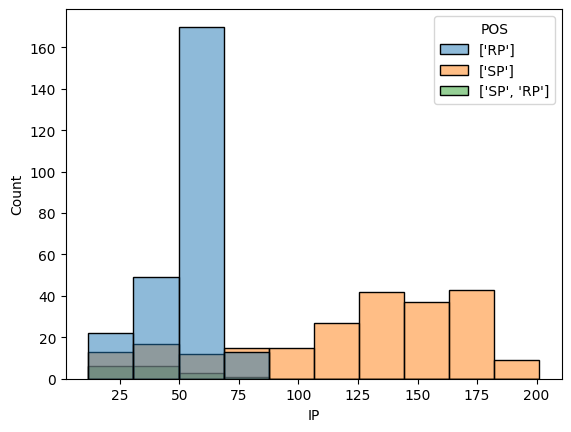

In [42]:
import seaborn as sns
sns.histplot(Pitcher_Projections_df[Pitcher_Projections_df['WAR']>0.05],x='IP',hue='POS')

In [43]:
League_Avg_HR9 = HR9(
            full_roster_P_stats['HR_avg'].values[0],
            full_roster_P_stats['IP_avg'].values[0])

League_Avg_SP_HR9 = HR9(
            full_roster_SP_stats['HR_avg'].values[0],
            full_roster_SP_stats['IP_avg'].values[0])

League_Avg_RP_HR9 = HR9(
            full_roster_RP_stats['HR_avg'].values[0],
            full_roster_RP_stats['IP_avg'].values[0])

League_Avg_ERA = ERA(
            full_roster_P_stats['ER_avg'].values[0],
            full_roster_P_stats['IP_avg'].values[0])

League_Avg_SP_ERA = ERA(
            full_roster_SP_stats['ER_avg'].values[0],
            full_roster_SP_stats['IP_avg'].values[0])

League_Avg_RP_ERA = ERA(
            full_roster_RP_stats['ER_avg'].values[0],
            full_roster_RP_stats['IP_avg'].values[0])

League_Avg_WHIP = WHIP(
            full_roster_P_stats['BB_avg'].values[0],
            full_roster_P_stats['H_avg'].values[0],
            full_roster_P_stats['IP_avg'].values[0]
)

League_Avg_SP_WHIP = WHIP(
            full_roster_SP_stats['BB_avg'].values[0],
            full_roster_SP_stats['H_avg'].values[0],
            full_roster_SP_stats['IP_avg'].values[0]
)

League_Avg_RP_WHIP = WHIP(
            full_roster_RP_stats['BB_avg'].values[0],
            full_roster_RP_stats['H_avg'].values[0],
            full_roster_RP_stats['IP_avg'].values[0]
)

# P League Average

In [44]:
print('HR9', League_Avg_HR9)
print('SP HR9', League_Avg_SP_HR9)
print('RP HR9', League_Avg_RP_HR9)
print('ERA', League_Avg_ERA)
print('SP ERA', League_Avg_SP_ERA)
print('RP ERA', League_Avg_RP_ERA)
print('WHIP', League_Avg_WHIP)
print('SP WHIP', League_Avg_SP_WHIP)
print('RP WHIP', League_Avg_RP_WHIP)

HR9 1.144810357523257
SP HR9 1.161565482340841
RP HR9 0.961453937231127
ERA 3.9515270349557325
SP ERA 3.9749147642107743
RP ERA 3.3826779530944577
WHIP 1.2549806064557654
SP WHIP 1.2526615876623133
RP WHIP 1.1926944367575265


In [45]:
Pitcher_Projections_df[Pitcher_Projections_df['Pos Place']<(Replacement_Level['P'])]

,PlayerId,MLBAMID,Name,Team,NameASCII,W,L,QS,G,GS,...,SO,WAR,ADP,POS,K,HR9,ERA,WHIP,Pos Place,K_SGP_raw
2,10233,547973,Aroldis Chapman,BOS,Aroldis Chapman,3.355612,3.199640,0.000000,61.23632,0.000000,...,82.58592,1.232904,46.840000,['RP'],82.58592,0.849794,2.957060,1.161047,145.0,1.737819
3,10310,554430,Zack Wheeler,PHI,Zack Wheeler,9.304912,5.024288,12.691840,20.43608,20.436080,...,144.48120,2.875334,148.449997,['SP'],144.48120,1.077212,3.156823,1.073152,29.0,3.040254
6,10603,519242,Chris Sale,ATL,Chris Sale,11.719560,7.419640,15.904440,27.12540,27.125400,...,195.78440,3.827484,34.709999,['SP'],195.78440,1.002222,3.233025,1.101263,7.0,4.119805
7,10954,594798,Jacob deGrom,TEX,Jacob deGrom,12.166440,7.737944,15.749920,28.16260,28.162600,...,187.21240,3.581484,47.349998,['SP'],187.21240,1.203461,3.310372,1.069086,13.0,3.939428
9,11156,518876,Merrill Kelly,ARI,Merrill Kelly,11.074600,10.016672,14.957760,30.01280,30.012800,...,159.21560,2.069470,229.899994,['SP'],159.21560,1.180407,4.176735,1.278588,72.0,3.350304
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
850,sa3007778,680802,Ryan Weiss,HOU,Ryan Weiss,4.651260,4.718760,5.061120,39.03556,9.620748,...,80.76716,0.627950,999.000000,['SP'],80.76716,1.183221,4.396182,1.359385,212.0,1.699548
1306,sa3017880,691725,Andrew Painter,PHI,Andrew Painter,4.628228,5.200972,9.273292,29.83484,20.036200,...,110.59116,1.251957,999.000000,['SP'],110.59116,1.273389,4.285487,1.342710,142.0,2.327121
1747,sa3020707,702281,Robby Snelling,MIA,Robby Snelling,7.029260,6.722076,9.363644,19.29048,19.290480,...,101.10884,1.520722,999.000000,['SP'],101.10884,1.096627,4.153501,1.323766,109.0,2.127589
2239,sa3023268,806258,Thomas White,MIA,Thomas White,4.215084,3.773152,5.235620,10.27906,10.279060,...,69.26380,0.843555,999.000000,['SP'],69.26380,1.067980,3.886331,1.385957,180.0,1.457488


<Axes: >

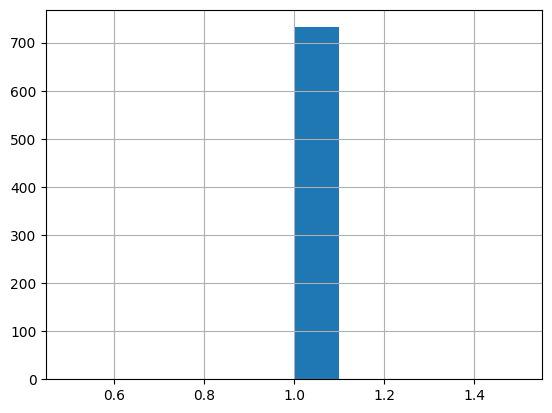

In [46]:
Pitcher_Projections_df['Pos Place'].value_counts().hist()

<Axes: xlabel='Pos Place', ylabel='Pos Place'>

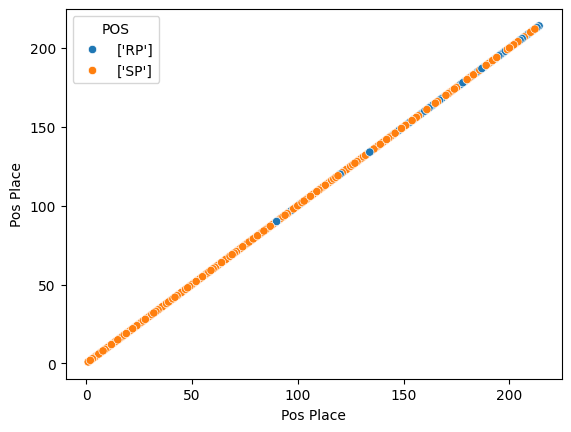

In [47]:
sns.scatterplot(Pitcher_Projections_df[Pitcher_Projections_df['Pos Place']<Replacement_Level['P']],x='Pos Place',y='Pos Place',hue='POS')

<Axes: xlabel='ERA', ylabel='Count'>

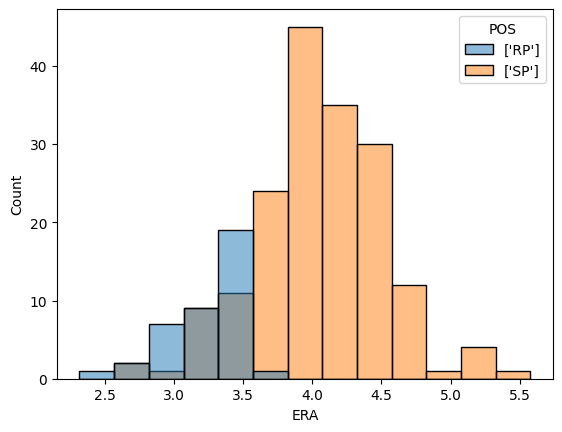

In [48]:
sns.histplot(Pitcher_Projections_df[Pitcher_Projections_df['Pos Place']<Replacement_Level['P']],x='ERA',hue='POS')

<Axes: xlabel='IP', ylabel='Count'>

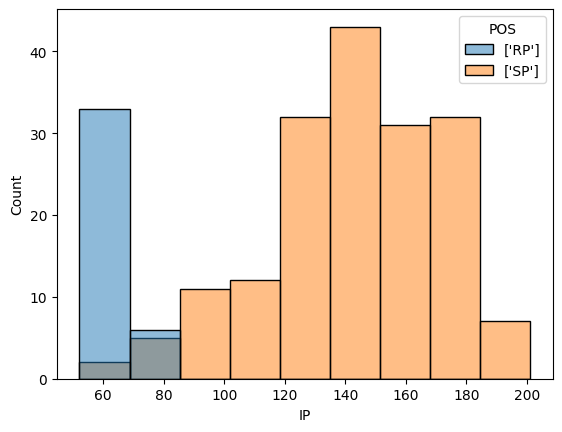

In [49]:
sns.histplot(Pitcher_Projections_df[Pitcher_Projections_df['Pos Place']<Replacement_Level['P']],x='IP',hue='POS')

In [50]:
Pitcher_Projections_df['POS'] == "['SP']"

0       False
1       False
2       False
3        True
4       False
        ...  
2663    False
2741     True
2845     True
3026    False
3040    False
Name: POS, Length: 732, dtype: bool

In [51]:
Pitcher_Projections_df['HR9_SGP_raw'] = (
    HR9(
        (Pitcher_Projections_df['HR'] \
         + np.where(
            (Pitcher_Projections_df['POS'] == "['SP']"),
            rest_of_roster_SP_stats['HR_avg'].values[0],
            rest_of_roster_RP_stats['HR_avg'].values[0]
            )
        ),
        (Pitcher_Projections_df['IP'] \
         + np.where(
            (Pitcher_Projections_df['POS'] == "['SP']"),
            rest_of_roster_SP_stats['IP_avg'].values[0],
            rest_of_roster_RP_stats['IP_avg'].values[0]
            )
        )
        )
    - np.where(
        (Pitcher_Projections_df['POS'] == "['SP']"),
        League_Avg_SP_HR9,
        League_Avg_RP_HR9
    )
) / SGP_Denom['HR9']

In [52]:
Pitcher_Projections_df['ERA_SGP_raw'] = (
    ERA(
        (Pitcher_Projections_df['ER'] \
         + np.where(
            (Pitcher_Projections_df['POS'] == "['SP']"),
            rest_of_roster_SP_stats['ER_avg'].values[0],
            rest_of_roster_RP_stats['ER_avg'].values[0]
            )
        ),
        (Pitcher_Projections_df['IP'] \
         + np.where(
            (Pitcher_Projections_df['POS'] == "['SP']"),
            rest_of_roster_SP_stats['IP_avg'].values[0],
            rest_of_roster_RP_stats['IP_avg'].values[0]
            )
        )
        )
    - np.where(
        (Pitcher_Projections_df['POS'] == "['SP']"),
        League_Avg_SP_ERA,
        League_Avg_RP_ERA
    )
) / SGP_Denom['ERA']

In [53]:
Pitcher_Projections_df['WHIP_SGP_raw'] = (
    WHIP(
        (Pitcher_Projections_df['BB'] \
         + np.where(
            (Pitcher_Projections_df['POS'] == "['SP']"),
            rest_of_roster_SP_stats['BB_avg'].values[0],
            rest_of_roster_RP_stats['BB_avg'].values[0]
            )
        ),
        (Pitcher_Projections_df['H'] \
         + np.where(
            (Pitcher_Projections_df['POS'] == "['SP']"),
            rest_of_roster_SP_stats['H_avg'].values[0],
            rest_of_roster_RP_stats['H_avg'].values[0]
            )
        ),
        (Pitcher_Projections_df['IP'] \
         + np.where(
            (Pitcher_Projections_df['POS'] == "['SP']"),
            rest_of_roster_SP_stats['IP_avg'].values[0],
            rest_of_roster_RP_stats['IP_avg'].values[0]
            )
        )
        )
    - np.where(
        (Pitcher_Projections_df['POS'] == "['SP']"),
        League_Avg_SP_WHIP,
        League_Avg_RP_WHIP
    )
) / SGP_Denom['WHIP']

In [54]:
Pitcher_Projections_df['TOTAL_SGP_raw'] = Pitcher_Projections_df[[f'{col}_SGP_raw' for col in Scoring_Categories_Pitching]].sum(axis=1)

In [55]:
Pitcher_Projections_df.sort_values('TOTAL_SGP_raw',ascending=False).head(10)

,PlayerId,MLBAMID,Name,Team,NameASCII,W,L,QS,G,GS,...,K,HR9,ERA,WHIP,Pos Place,K_SGP_raw,HR9_SGP_raw,ERA_SGP_raw,WHIP_SGP_raw,TOTAL_SGP_raw
384,22267,669373,Tarik Skubal,DET,Tarik Skubal,15.349680,7.016644,21.063400,31.15064,31.15064,...,239.87600,0.882934,2.687728,0.987149,1.0,5.047605,1.106802,1.488411,1.573518,9.216336
770,33677,694973,Paul Skenes,PIT,Paul Skenes,14.546840,8.081052,20.244960,31.28424,31.28424,...,231.92120,0.790954,2.767541,1.051617,2.0,4.880216,1.435879,1.361702,1.162084,8.839881
574,27463,676979,Garrett Crochet,BOS,Garrett Crochet,14.298760,8.058244,18.816000,30.92356,30.92356,...,232.46840,0.904065,3.008174,1.074135,3.0,4.891730,0.983511,1.074863,1.017305,7.967409
739,31757,695243,Mason Miller,SDP,Mason Miller,3.076936,2.781668,0.021111,64.23908,0.02887,...,100.44440,0.806302,2.315414,0.993832,90.0,2.113607,1.119679,2.242080,2.141107,7.616474
313,20778,650911,Cristopher Sánchez,PHI,Cristopher Sanchez,13.950640,8.509576,19.210720,30.93348,30.93348,...,194.66960,0.815298,3.207583,1.146105,4.0,4.096347,1.361738,0.878430,0.625184,6.961699
165,17995,657277,Logan Webb,SFG,Logan Webb,13.585360,9.458360,18.867920,31.32116,31.32116,...,193.48320,0.765265,3.392781,1.189805,5.0,4.071382,1.589869,0.679832,0.376213,6.717295
318,21029,661395,Jhoan Duran,PHI,Jhoan Duran,4.204012,3.459152,0.000000,69.25068,0.00000,...,81.56272,0.659828,2.709456,1.110158,97.0,1.716289,2.262454,1.469979,0.923643,6.372365
711,30279,693433,Bryan Woo,SEA,Bryan Woo,14.292640,8.666328,18.715160,31.01756,31.01756,...,200.26880,1.150858,3.224773,1.046878,12.0,4.214168,0.041419,0.844703,1.187619,6.287908
6,10603,519242,Chris Sale,ATL,Chris Sale,11.719560,7.419640,15.904440,27.12540,27.12540,...,195.78440,1.002222,3.233025,1.101263,7.0,4.119805,0.528997,0.716967,0.749871,6.115639
46,13743,608331,Max Fried,NYY,Max Fried,13.497880,8.656616,17.732800,30.20236,30.20236,...,179.52080,0.881906,3.331856,1.184637,10.0,3.777577,1.042366,0.697724,0.378272,5.895940


<Axes: >

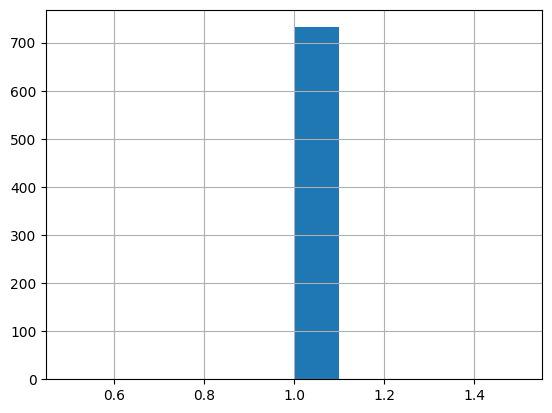

In [56]:
Pitcher_Projections_df.PlayerId.value_counts().hist()

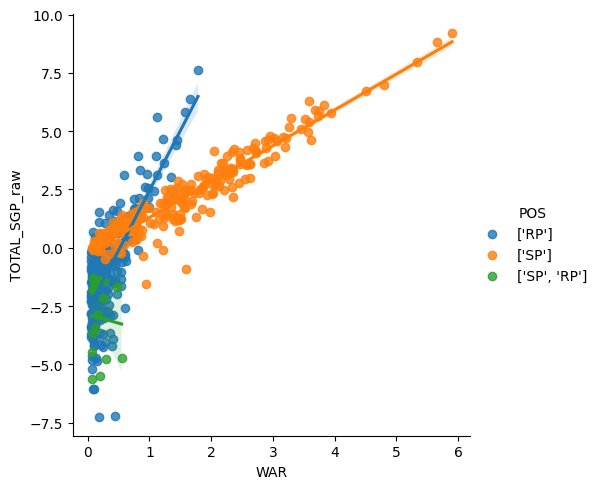

In [57]:
sns.lmplot(Pitcher_Projections_df[Pitcher_Projections_df['WAR']>0.05],x='WAR',y='TOTAL_SGP_raw',hue='POS')

# Replacement Level SGP

In [58]:
Hitting_Replacement_pivot_df = Hitting_Replacement_Stats_df.pivot_table('mean','POS','Stat').reset_index()

In [59]:
Hitting_Replacement_pivot_df

Stat,POS,1B_repl,2B_repl,3B_repl,AB_repl,ADP_repl,BB_repl,G_repl,HBP_repl,HR_repl,H_repl,PA_repl,RBI_repl,R_repl,SF_repl,WAR_repl
0,1B,30.252780,9.842962,0.817708,205.750330,596.141998,16.977879,54.421330,2.672852,8.315246,49.348708,227.758930,27.683857,26.621135,1.690244,0.347463
1,2B,66.755112,20.726440,2.396470,403.174800,479.063995,39.939864,107.595648,5.502096,10.037695,99.555704,453.698160,46.978072,53.466184,3.287539,1.375167
2,3B,83.314720,23.798592,1.575662,486.776720,437.371997,40.234752,127.349200,4.098032,11.708834,120.517688,537.183200,54.823168,58.908040,3.855494,1.330681
3,C,57.605329,16.847775,1.123042,368.688800,436.313998,35.697647,105.117627,3.218982,12.411811,87.953671,411.733097,46.061157,46.176634,2.849641,1.681751
4,DH,50.579605,15.991245,0.500085,358.067257,493.096002,34.054695,96.957921,4.584483,15.569905,82.640845,400.247589,49.930494,45.259478,2.689076,0.923805
5,OF,62.960306,19.781277,1.920478,419.726309,451.348004,42.488990,112.952883,6.868171,14.393717,99.055790,474.255543,52.807911,55.803808,3.342437,0.874515
6,SS,13.423092,4.390418,0.264605,91.201392,833.593994,7.412391,24.797544,1.124192,2.419746,20.257856,100.845152,9.849939,11.161982,0.615311,0.227796


In [60]:
Hitting_Replacement_SGP_df = pd.DataFrame()
for pos in Hitting_Pos:
    this_pos_repl_df = Hitting_Replacement_pivot_df[Hitting_Replacement_pivot_df['POS'] == pos]
    This_pos_dict = {
            'POS':pos,
        }
    for stat in Count_Scoring_Categories_Batting:
        Repl_mean = this_pos_repl_df[f'{stat}_repl'].values[0]

        This_pos_dict[f'{stat}_SGP'] = Repl_mean/SGP_Denom[stat]

    This_pos_dict['OBP_SGP'] = (OBP(
        (this_pos_repl_df['H_repl'].values[0]+rest_of_roster_stats['H_avg'].values[0]),
        (this_pos_repl_df['BB_repl'].values[0]+rest_of_roster_stats['BB_avg'].values[0]),
        (this_pos_repl_df['HBP_repl'].values[0]+rest_of_roster_stats['HBP_avg'].values[0]),
        (this_pos_repl_df['SF_repl'].values[0]+rest_of_roster_stats['SF_avg'].values[0]),
        (this_pos_repl_df['AB_repl'].values[0]+rest_of_roster_stats['AB_avg'].values[0])) \
    - full_roster_OBP) / SGP_Denom['OBP']
    
    repl_level_TB = TB(
    this_pos_repl_df['1B_repl'].values[0],
    this_pos_repl_df['2B_repl'].values[0],
    this_pos_repl_df['3B_repl'].values[0],
    this_pos_repl_df['HR_repl'].values[0])

    This_pos_dict['SLG_SGP'] = (
    SLG(
        (repl_level_TB+rest_of_roster_TB),
        (this_pos_repl_df['AB_repl'].values[0]+rest_of_roster_stats['AB_avg'].values[0])) \
    -  full_roster_SLG) / SGP_Denom['SLG']
    Hitting_Replacement_SGP_df = pd.concat([
        Hitting_Replacement_SGP_df,
        pd.DataFrame([This_pos_dict])
    ])

In [61]:
Hitting_Replacement_SGP_df

,POS,R_SGP,HR_SGP,OBP_SGP,SLG_SGP
0,C,1.826425,1.078500,-0.269056,-0.258195
0,1B,1.052946,0.722537,-0.197903,-0.041125
0,2B,2.114749,0.872206,-0.092919,-0.327108
0,SS,0.441490,0.210259,-0.155311,-0.128969
0,3B,2.329991,1.017416,-0.365619,-0.498094
0,OF,2.207209,1.250714,-0.217234,-0.260807
0,DH,1.790149,1.352916,-0.345087,-0.125587


In [62]:
Hitter_Projections_df[Hitter_Projections_df['PlayerId'] == '16578']['POS'].apply(lambda x : min(Hitting_Replacement_SGP_df[Hitting_Replacement_SGP_df['POS'].isin(eval(x))]['R_SGP']))

75    1.052946
Name: POS, dtype: float64

In [63]:
for stat in Scoring_Categories_Batting:
    Hitter_Projections_df[f'{stat}_SGP_norm'] = Hitter_Projections_df[f'{stat}_SGP_raw'] - Hitter_Projections_df['POS'].apply(lambda x : min(Hitting_Replacement_SGP_df[Hitting_Replacement_SGP_df['POS'].isin(eval(x))][f'{stat}_SGP']))

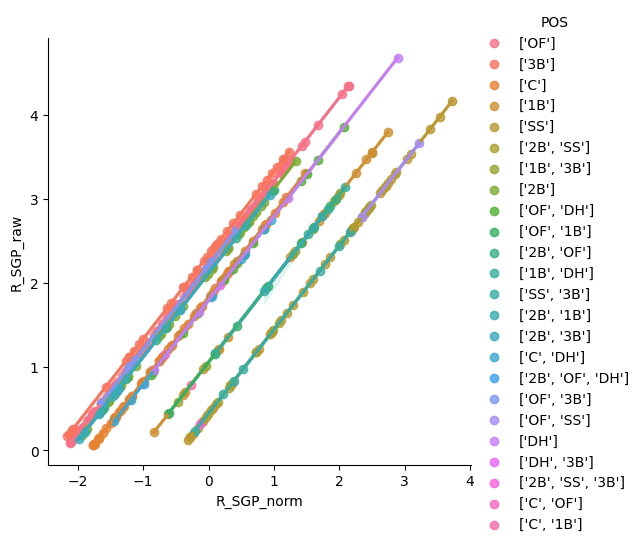

In [64]:
sns.lmplot(Hitter_Projections_df[Hitter_Projections_df['WAR']>0.05],x='R_SGP_norm',y='R_SGP_raw',hue='POS')

In [65]:
Pitching_Replacement_pivot_df = Pitching_Replacement_Stats_df.pivot_table('mean','POS','Stat').reset_index()

In [66]:
Pitching_Replacement_pivot_df

Stat,POS,ADP_repl,BB_repl,ER_repl,GS_repl,G_repl,HBP_repl,HLD_repl,HR_repl,H_repl,IP_repl,K_repl,L_repl,QS_repl,R_repl,SV_repl,TBF_repl,WAR_repl,W_repl
0,P,332.941997,22.647632,26.418112,0.013764,65.159536,3.100856,10.392215,7.963604,56.119152,64.792808,70.077928,3.132582,0.000000,28.929248,13.086915,272.14856,0.612410,3.257773
1,RP,590.018005,24.127544,26.262608,0.043568,63.023536,3.042842,12.018269,6.823272,55.747072,62.923208,65.279832,3.164778,0.000000,28.629784,6.980603,266.89224,0.466813,3.216506
2,SP,611.043994,39.633032,52.844904,15.541649,35.827440,4.940795,0.850815,15.447660,103.408240,106.547576,95.894872,4.759955,7.016453,57.669688,0.005985,459.33768,0.938272,3.898110


In [67]:
Pitching_Replacement_SGP_df = pd.DataFrame()
for pos in Pitching_Pos:
    this_pos_repl_df = Pitching_Replacement_pivot_df[Pitching_Replacement_pivot_df['POS'] == pos]
    This_pos_dict = {
            'POS':pos,
        }
    for stat in Count_Scoring_Categories_Pitching:
        Repl_mean = this_pos_repl_df[f'{stat}_repl'].values[0]

        This_pos_dict[f'{stat}_SGP'] = Repl_mean/SGP_Denom[stat]

    This_pos_dict['HR9_SGP'] = (
    HR9(
        np.where(
            pos == 'SP',
            (this_pos_repl_df['HR_repl'].values[0]+rest_of_roster_SP_stats['HR_avg'].values[0]),
            (this_pos_repl_df['HR_repl'].values[0]+rest_of_roster_RP_stats['HR_avg'].values[0])
        ),
        np.where(
            pos == 'SP',
            (this_pos_repl_df['IP_repl'].values[0]+rest_of_roster_SP_stats['IP_avg'].values[0]),
            (this_pos_repl_df['IP_repl'].values[0]+rest_of_roster_RP_stats['IP_avg'].values[0])
        )) \
    - np.where(
        pos == 'SP',
        HR9(
            full_roster_SP_stats['HR_avg'].values[0],
            full_roster_SP_stats['IP_avg'].values[0]),
        HR9(
            full_roster_RP_stats['HR_avg'].values[0],
            full_roster_RP_stats['IP_avg'].values[0])     
    ) ) / SGP_Denom['HR9']

    This_pos_dict['ERA_SGP'] = (
    ERA(
        np.where(
            pos == 'SP',
            (this_pos_repl_df['ER_repl'].values[0]+rest_of_roster_SP_stats['ER_avg'].values[0]),
            (this_pos_repl_df['ER_repl'].values[0]+rest_of_roster_RP_stats['ER_avg'].values[0])
        ),
        np.where(
            pos == 'SP',
            (this_pos_repl_df['IP_repl'].values[0]+rest_of_roster_SP_stats['IP_avg'].values[0]),
            (this_pos_repl_df['IP_repl'].values[0]+rest_of_roster_RP_stats['IP_avg'].values[0])
        )) \
    - np.where(
        pos == 'SP',
        ERA(
            full_roster_SP_stats['ER_avg'].values[0],
            full_roster_SP_stats['IP_avg'].values[0]),
        ERA(
            full_roster_RP_stats['ER_avg'].values[0],
            full_roster_RP_stats['IP_avg'].values[0])     
    ) ) / SGP_Denom['ERA']

    This_pos_dict['WHIP_SGP'] = (
    WHIP(
        np.where(
            pos == 'SP',
            (this_pos_repl_df['BB_repl'].values[0]+rest_of_roster_SP_stats['BB_avg'].values[0]),
            (this_pos_repl_df['BB_repl'].values[0]+rest_of_roster_RP_stats['BB_avg'].values[0])
        ),
        np.where(
            pos == 'SP',
            (this_pos_repl_df['H_repl'].values[0]+rest_of_roster_SP_stats['H_avg'].values[0]),
            (this_pos_repl_df['H_repl'].values[0]+rest_of_roster_RP_stats['H_avg'].values[0])
        ),
        np.where(
            pos == 'SP',
            (this_pos_repl_df['IP_repl'].values[0]+rest_of_roster_SP_stats['IP_avg'].values[0]),
            (this_pos_repl_df['IP_repl'].values[0]+rest_of_roster_RP_stats['IP_avg'].values[0])
        )) \
    - np.where(
        pos == 'SP',
        WHIP(
            full_roster_SP_stats['BB_avg'].values[0],
            full_roster_SP_stats['H_avg'].values[0],
            full_roster_SP_stats['IP_avg'].values[0]),
        WHIP(
            full_roster_RP_stats['BB_avg'].values[0],
            full_roster_RP_stats['H_avg'].values[0],
            full_roster_RP_stats['IP_avg'].values[0])     
    ) ) / SGP_Denom['WHIP']

    Pitching_Replacement_SGP_df = pd.concat([
        Pitching_Replacement_SGP_df,
        pd.DataFrame([This_pos_dict])
    ])

In [68]:
Pitching_Replacement_SGP_df

,POS,K_SGP,HR9_SGP,ERA_SGP,WHIP_SGP
0,SP,2.017874,-0.320269,-0.318076,-0.299618
0,RP,1.373655,-0.100776,-0.756644,-0.795956
0,P,1.474619,-1.030991,-0.594979,-0.244207


In [69]:
for stat in Scoring_Categories_Pitching:
    Pitcher_Projections_df[f'{stat}_SGP_norm'] = Pitcher_Projections_df[f'{stat}_SGP_raw'] - Pitcher_Projections_df['POS'].apply(lambda x : min(Pitching_Replacement_SGP_df[Pitching_Replacement_SGP_df['POS'].isin(eval(x))][f'{stat}_SGP']))

In [70]:
Pitcher_Projections_df['TOTAL_SGP'] = Pitcher_Projections_df[[f'{col}_SGP_norm' for col in Scoring_Categories_Pitching]].sum(axis=1)
Hitter_Projections_df['TOTAL_SGP'] = Hitter_Projections_df[[f'{col}_SGP_norm' for col in Scoring_Categories_Batting]].sum(axis=1)

In [71]:
Hitter_Projections_df.sort_values(['TOTAL_SGP'])

,PlayerId,MLBAMID,Name,Team,NameASCII,G,PA,AB,H,1B,...,R_SGP_raw,HR_SGP_raw,OBP_SGP_raw,SLG_SGP_raw,TOTAL_SGP_raw,R_SGP_norm,HR_SGP_norm,OBP_SGP_norm,SLG_SGP_norm,TOTAL_SGP
401,26149,666150,Dominic Fletcher,PIT,Dominic Fletcher,2.0000,7.0000,6.0000,1.0000,1.00000,...,0.039553,0.000000,-0.038030,-0.032812,-0.031289,-2.167656,-1.250714,0.179204,0.227994,-3.011171
1980,sa918983,670208,Matt Fraizer,BOS,Matt Fraizer,0.0000,1.0000,1.0000,0.0000,0.00000,...,0.000000,0.000000,-0.012964,-0.008989,-0.021952,-2.207209,-1.250714,0.204270,0.251818,-3.001834
617,sa3005712,672537,Dalvy Rosario,MIA,Dalvy Rosario,0.0000,1.0000,1.0000,0.0000,0.00000,...,0.000000,0.000000,-0.012964,-0.008989,-0.021952,-2.207209,-1.250714,0.204270,0.251818,-3.001834
1273,sa3021278,808516,Andres Valor,MIA,Andres Valor,0.0000,1.0000,1.0000,0.0000,0.00000,...,0.000000,0.000000,-0.012964,-0.008989,-0.021952,-2.207209,-1.250714,0.204270,0.251818,-3.001834
1272,sa3021277,808504,Andru Arthur,STL,Andru Arthur,0.0000,1.0000,1.0000,0.0000,0.00000,...,0.000000,0.000000,-0.012964,-0.008989,-0.021952,-2.207209,-1.250714,0.204270,0.251818,-3.001834
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
162,19611,665489,Vladimir Guerrero Jr.,TOR,Vladimir Guerrero Jr.,156.3660,676.0260,588.6444,176.8876,110.61760,...,3.792140,2.728834,1.426143,1.112031,9.059148,2.739193,2.006297,1.624046,1.153156,7.522692
200,20123,665742,Juan Soto,NYM,Juan Soto,157.9752,684.2876,552.7056,154.5760,88.31900,...,4.246365,3.374845,2.160035,1.312412,11.093658,2.039156,2.124132,2.377269,1.573219,8.113776
375,25764,677951,Bobby Witt Jr.,KCR,Bobby Witt Jr.,156.0036,674.3132,610.9472,182.2136,107.51320,...,4.165962,2.645945,0.748301,1.264189,8.824396,3.724472,2.435686,0.903611,1.393158,8.456926
169,19755,660271,Shohei Ohtani,LAD,Shohei Ohtani,154.5648,675.7600,576.2060,164.7624,82.63564,...,4.683078,4.219974,1.464080,2.094678,12.461810,2.892929,2.867058,1.809167,2.220266,9.789419


<Axes: xlabel='ADP', ylabel='TOTAL_SGP'>

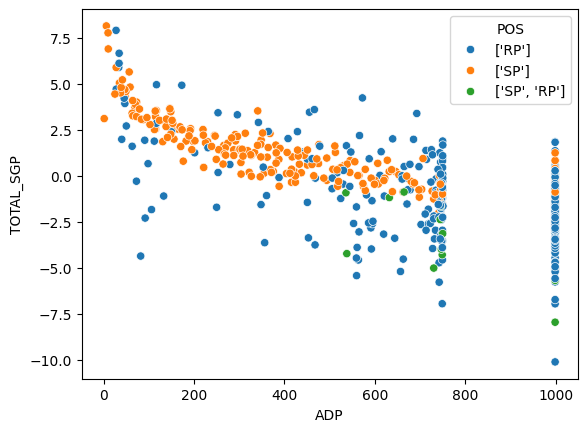

In [72]:
sns.scatterplot(Pitcher_Projections_df,y='TOTAL_SGP',x='ADP',hue='POS')

In [73]:
Pitcher_Projections_df['TOTAL_SGP_Rank'] = Pitcher_Projections_df['TOTAL_SGP'].rank(ascending=False)
Hitter_Projections_df['TOTAL_SGP_Rank'] = Hitter_Projections_df['TOTAL_SGP'].rank(ascending=False)

<Axes: xlabel='TOTAL_SGP_Rank', ylabel='TOTAL_SGP'>

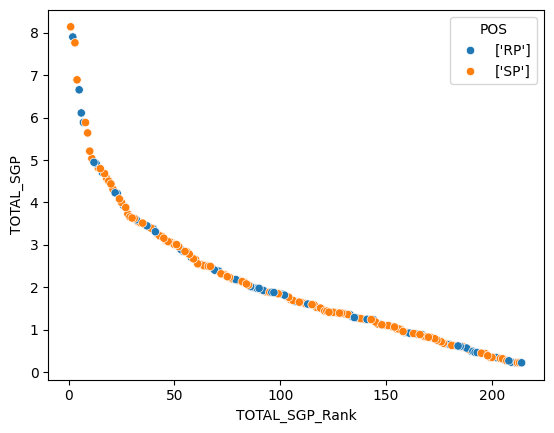

In [74]:
sns.scatterplot(Pitcher_Projections_df[Pitcher_Projections_df['TOTAL_SGP_Rank'] < Replacement_Level['P']],x='TOTAL_SGP_Rank',y='TOTAL_SGP',hue='POS')

<Axes: xlabel='TOTAL_SGP', ylabel='Count'>

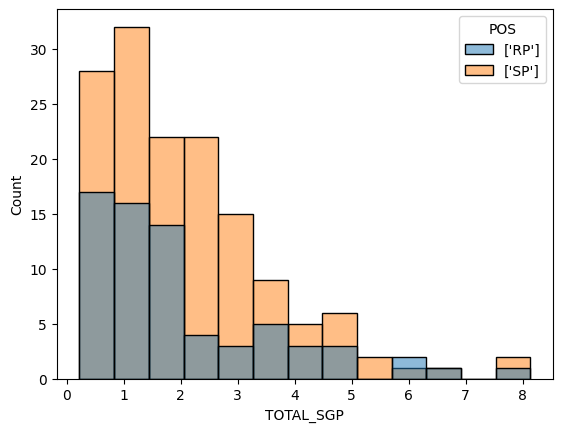

In [75]:
sns.histplot(Pitcher_Projections_df[Pitcher_Projections_df['TOTAL_SGP_Rank'] < Replacement_Level['P']],x='TOTAL_SGP',hue='POS')

<Axes: xlabel='TOTAL_SGP_Rank', ylabel='TOTAL_SGP'>

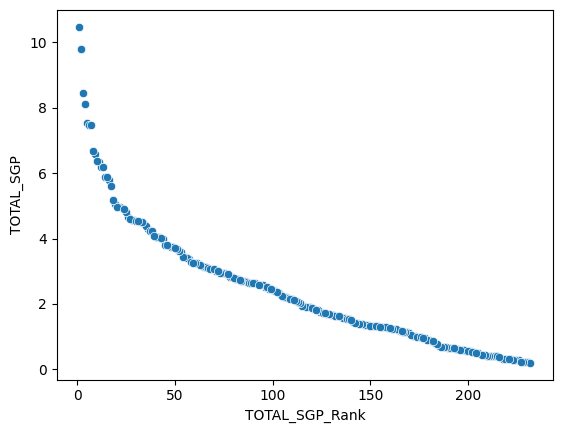

In [76]:
sns.scatterplot(Hitter_Projections_df[Hitter_Projections_df['TOTAL_SGP_Rank'] < Replacement_Level['DH']],x='TOTAL_SGP_Rank',y='TOTAL_SGP')

In [77]:
Hitter_Projections_df[Hitter_Projections_df['TOTAL_SGP'] > 0.]['TOTAL_SGP'].count()/Num_teams

np.float64(20.833333333333332)

In [78]:
Pitcher_Projections_df[(Pitcher_Projections_df['TOTAL_SGP'] > 0.)].groupby('POS')['TOTAL_SGP'].count()/Num_teams

POS
['RP']     6.833333
['SP']    13.250000
Name: TOTAL_SGP, dtype: float64

<Axes: xlabel='TOTAL_SGP', ylabel='Count'>

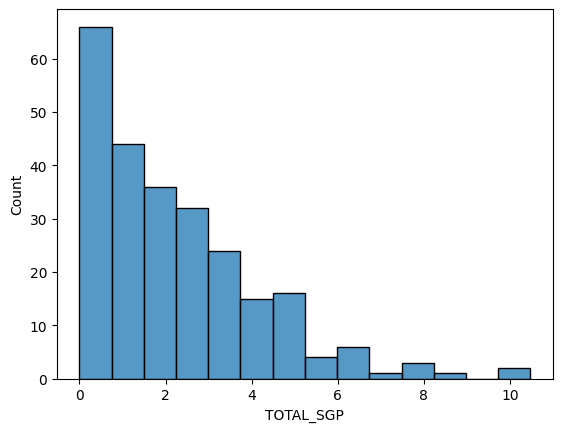

In [79]:
sns.histplot(Hitter_Projections_df[Hitter_Projections_df['TOTAL_SGP'] > 0.],x='TOTAL_SGP')

<Axes: xlabel='TOTAL_SGP', ylabel='Count'>

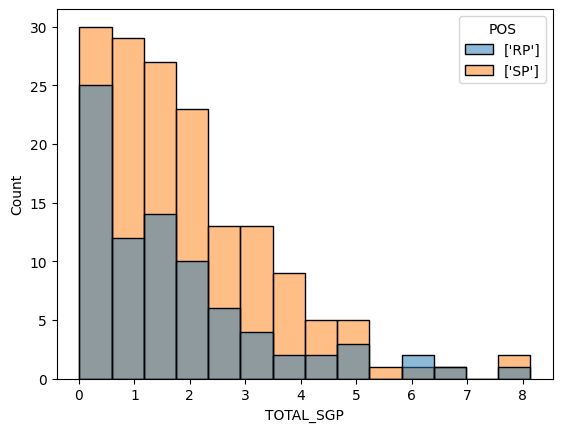

In [80]:
sns.histplot(Pitcher_Projections_df[(Pitcher_Projections_df['TOTAL_SGP'] > 0.)],x='TOTAL_SGP',hue='POS')

In [81]:
# Hitter_Projections_df[Hitter_Projections_df['TOTAL_SGP_Rank'] < Replacement_Level['DH']]['TOTAL_SGP'].sum()

In [82]:
Val_per_SGP_Hitter = Hitter_budget/(Hitter_Projections_df[Hitter_Projections_df['TOTAL_SGP_Rank'] < Replacement_Level['DH']]['TOTAL_SGP'].sum())

In [83]:
Val_per_SGP_Hitter

np.float64(4.528680875754556)

In [84]:
Hitter_Projections_df['TOTAL_SGP_Val'] = Hitter_Projections_df['TOTAL_SGP']*Val_per_SGP_Hitter

In [85]:
Hitter_Projections_df[Hitter_Projections_df['TOTAL_SGP_Rank'] < Replacement_Level['DH']]['TOTAL_SGP'].count()

np.int64(232)

In [86]:
Hitter_Projections_df[Hitter_Projections_df['TOTAL_SGP_Val'] >= 1.]['TOTAL_SGP_Val'].sum()/Num_teams

np.float64(211.76099993712762)

In [87]:
for stat in Scoring_Categories_Batting:
    Val_per_stat_SGP_Hitter = Hitter_budget/(Hitter_Projections_df[Hitter_Projections_df['TOTAL_SGP_Rank'] < Replacement_Level['DH']][f'{stat}_SGP_norm'].sum())
    Hitter_Projections_df[f'{stat}_SGP_Val'] = Hitter_Projections_df[f'{stat}_SGP_norm']*Val_per_stat_SGP_Hitter
    print(stat, Hitter_Projections_df[Hitter_Projections_df['TOTAL_SGP_Val'] >= 1.][f'{stat}_SGP_Val'].sum()/Num_teams)

R 212.43828928542982
HR 212.40142306606154
OBP 209.11673720282758
SLG 209.82147887785877


<Axes: xlabel='TOTAL_SGP_Val', ylabel='Count'>

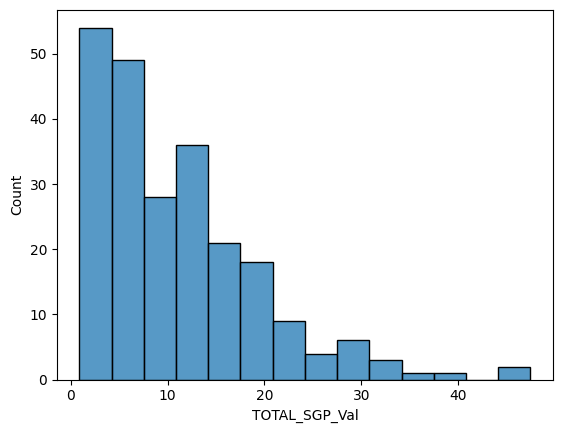

In [88]:
sns.histplot(Hitter_Projections_df[Hitter_Projections_df['TOTAL_SGP_Rank'] < Replacement_Level['DH']],x='TOTAL_SGP_Val')

In [89]:
print(f'Pct bias Hitting: {(Hitter_Projections_df[Hitter_Projections_df['TOTAL_SGP_Val'] >= 1.]['TOTAL_SGP_Val'].sum() - Hitter_budget)/Hitter_budget*100:.2f}%')

Pct bias Hitting: -0.11%


<Axes: xlabel='TOTAL_SGP_Val', ylabel='TOTAL_SGP'>

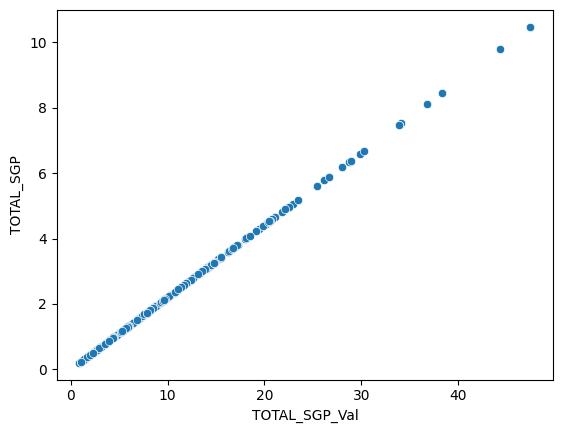

In [90]:
sns.scatterplot(Hitter_Projections_df[Hitter_Projections_df['TOTAL_SGP_Rank'] < Replacement_Level['DH']],x='TOTAL_SGP_Val',y='TOTAL_SGP')

In [91]:
# Pitcher_Projections_df[Pitcher_Projections_df['TOTAL_SGP_Rank'] < Replacement_Level['P']]['TOTAL_SGP'].sum()

In [92]:
Val_per_SGP_Pitcher = Pitcher_budget/(Pitcher_Projections_df[Pitcher_Projections_df['TOTAL_SGP_Rank'] < Replacement_Level['DH']]['TOTAL_SGP'].sum())

In [93]:
Pitcher_Projections_df['TOTAL_SGP_Val'] = Pitcher_Projections_df['TOTAL_SGP']*Val_per_SGP_Pitcher

In [94]:
Pitcher_Projections_df[Pitcher_Projections_df['TOTAL_SGP_Rank'] < Replacement_Level['P']]['TOTAL_SGP'].count()

np.int64(214)

In [95]:
Pitcher_Projections_df[Pitcher_Projections_df['TOTAL_SGP_Val'] >= 1.]['TOTAL_SGP'].count()

np.int64(216)

In [96]:
Pitcher_Projections_df[Pitcher_Projections_df['TOTAL_SGP_Val'] >= 1.]['TOTAL_SGP_Val'].sum()/Num_teams

np.float64(187.0533680963929)

In [97]:
for stat in Scoring_Categories_Pitching:
    Val_per_stat_SGP_Pitcher = Pitcher_budget/(Pitcher_Projections_df[Pitcher_Projections_df['TOTAL_SGP_Rank'] < Replacement_Level['P']][f'{stat}_SGP_norm'].sum())
    Pitcher_Projections_df[f'{stat}_SGP_Val'] = Pitcher_Projections_df[f'{stat}_SGP_norm']*Val_per_stat_SGP_Pitcher
    print(stat, Pitcher_Projections_df[Pitcher_Projections_df['TOTAL_SGP_Val'] >= 1.][f'{stat}_SGP_Val'].sum()/Num_teams)

K 187.60712929871775
HR9 187.78566490561636
ERA 188.69911572261356
WHIP 188.8328826586927


In [98]:
print(f'Pct bias Pitching: {(Pitcher_Projections_df[Pitcher_Projections_df['TOTAL_SGP_Val'] >= 1.]['TOTAL_SGP_Val'].sum() - Pitcher_budget)/Pitcher_budget*100:.2f}%')

Pct bias Pitching: -0.50%


<Axes: xlabel='TOTAL_SGP_Val', ylabel='TOTAL_SGP'>

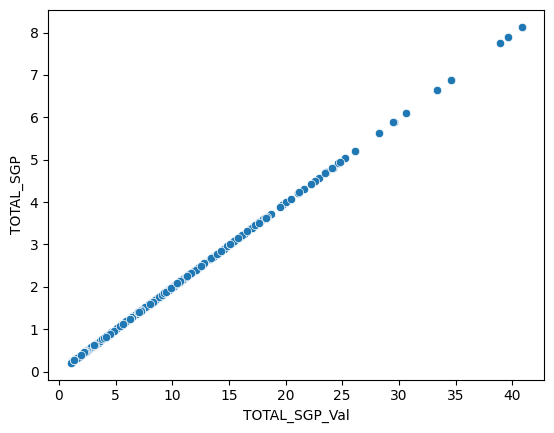

In [99]:
sns.scatterplot(Pitcher_Projections_df[Pitcher_Projections_df['TOTAL_SGP_Val'] >= 1.],x='TOTAL_SGP_Val',y='TOTAL_SGP')

In [100]:
Pitcher_Projections_df[Player_id_cols+['IP','K','HR9','ERA','WHIP','K_SGP_Val','HR9_SGP_Val','ERA_SGP_Val','WHIP_SGP_Val','TOTAL_SGP','TOTAL_SGP_Val']].sort_values('TOTAL_SGP_Val',ascending=False)

,PlayerId,MLBAMID,POS,Name,Team,NameASCII,IP,K,HR9,ERA,WHIP,K_SGP_Val,HR9_SGP_Val,ERA_SGP_Val,WHIP_SGP_Val,TOTAL_SGP,TOTAL_SGP_Val
384,22267,669373,['SP'],Tarik Skubal,DET,Tarik Skubal,198.89880,239.87600,0.882934,2.687728,0.987149,46.904098,34.719347,35.962360,44.433943,8.136427,40.828988
739,31757,695243,['RP'],Mason Miller,SDP,Mason Miller,65.83292,100.44440,0.806302,2.315414,0.993832,11.455406,29.692548,59.696629,69.672084,7.896195,39.623492
770,33677,694973,['SP'],Paul Skenes,PIT,Paul Skenes,193.44560,231.92120,0.790954,2.767541,1.051617,44.312698,42.725493,33.439928,34.674034,7.759972,38.939918
574,27463,676979,['SP'],Garrett Crochet,BOS,Garrett Crochet,190.40240,232.46840,0.904065,3.008174,1.074135,44.490957,31.719785,27.729717,31.239634,6.887499,34.561810
318,21029,661395,['RP'],Jhoan Duran,PHI,Jhoan Duran,69.05388,81.56272,0.659828,2.709456,1.110158,5.304405,57.495233,44.326144,40.791785,6.652086,33.380493
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
724,31552,688642,['RP'],Zach Agnos,COL,Zach Agnos,48.61224,40.41948,1.437977,5.127168,1.472559,-8.098647,-62.519385,-41.591757,-36.626121,-6.726124,-33.752021
140,17556,623474,['RP'],Jimmy Herget,COL,Jimmy Herget,79.68184,73.30852,1.395411,4.645474,1.355101,2.615470,-86.264395,-46.429314,-29.416290,-6.949117,-34.871008
152,17735,641302,['RP'],Tyler Alexander,TEX,Tyler Alexander,80.33708,65.90980,1.451399,4.643524,1.301622,0.205222,-98.352769,-46.728131,-13.720155,-6.955006,-34.900559
270,20070,663559,"['SP', 'RP']",Bailey Falter,KCR,Bailey Falter,71.32948,49.93300,1.432092,5.032285,1.382758,-4.999470,-80.357848,-58.531484,-32.903233,-7.953139,-39.909243


<Axes: xlabel='TOTAL_SGP_Val', ylabel='K_SGP_Val'>

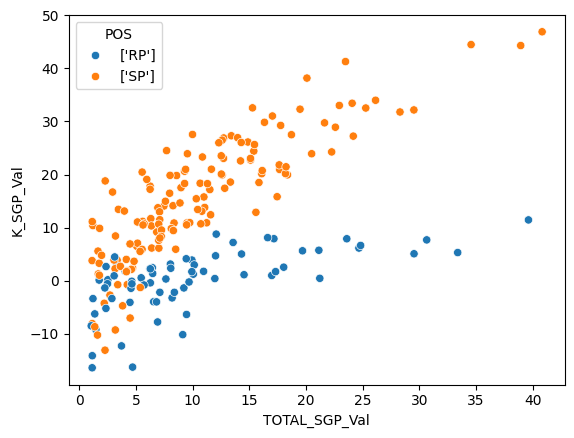

In [101]:
sns.scatterplot(Pitcher_Projections_df[Pitcher_Projections_df['TOTAL_SGP_Val'] >= 1.],x='TOTAL_SGP_Val',y='K_SGP_Val',hue='POS')

<Axes: xlabel='TOTAL_SGP_Val', ylabel='HR9_SGP_Val'>

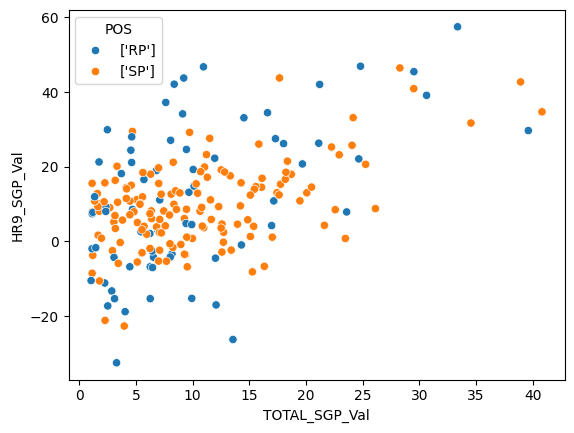

In [102]:
sns.scatterplot(Pitcher_Projections_df[Pitcher_Projections_df['TOTAL_SGP_Val'] >= 1.],x='TOTAL_SGP_Val',y='HR9_SGP_Val',hue='POS')

<Axes: xlabel='TOTAL_SGP_Val', ylabel='ERA_SGP_Val'>

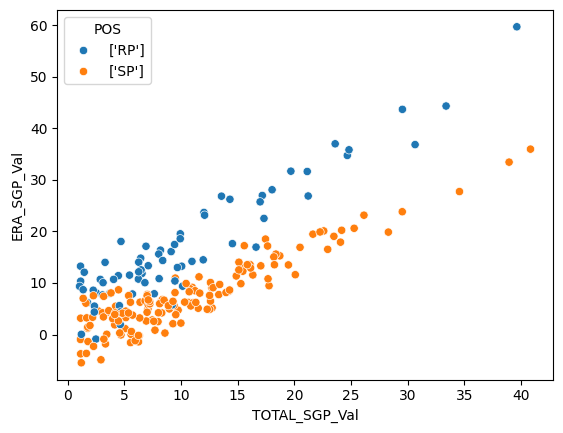

In [103]:
sns.scatterplot(Pitcher_Projections_df[Pitcher_Projections_df['TOTAL_SGP_Val'] >= 1.],x='TOTAL_SGP_Val',y='ERA_SGP_Val',hue='POS')

<Axes: xlabel='TOTAL_SGP_Val', ylabel='WHIP_SGP_Val'>

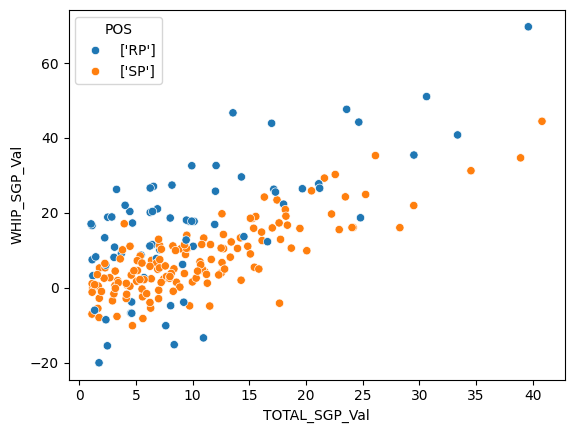

In [104]:
sns.scatterplot(Pitcher_Projections_df[Pitcher_Projections_df['TOTAL_SGP_Val'] >= 1.],x='TOTAL_SGP_Val',y='WHIP_SGP_Val',hue='POS')

In [105]:
Hitter_Projections_df[Player_id_cols+['G','R','HR','OBP','SLG','R_SGP_Val','HR_SGP_Val','OBP_SGP_Val','SLG_SGP_Val','TOTAL_SGP','TOTAL_SGP_Val']].sort_values('TOTAL_SGP_Val',ascending=False)

,PlayerId,MLBAMID,POS,Name,Team,NameASCII,G,R,HR,OBP,SLG,R_SGP_Val,HR_SGP_Val,OBP_SGP_Val,SLG_SGP_Val,TOTAL_SGP,TOTAL_SGP_Val
59,15640,592450,['OF'],Aaron Judge,NYY,Aaron Judge,153.0252,109.91000,51.31892,0.422946,0.636914,21.744115,44.376933,116.114298,91.091349,10.472868,47.428279
169,19755,660271,['DH'],Shohei Ohtani,LAD,Shohei Ohtani,154.5648,118.40000,48.56516,0.384457,0.609322,29.393604,39.653897,80.657308,80.263619,9.789419,44.333156
375,25764,677951,['SS'],Bobby Witt Jr.,KCR,Bobby Witt Jr.,156.0036,105.32600,30.45060,0.356083,0.530721,37.842495,33.687649,40.285301,50.363294,8.456926,38.298721
200,20123,665742,['OF'],Juan Soto,NYM,Juan Soto,157.9752,107.35880,38.83908,0.411102,0.545443,20.718843,29.378586,105.984737,56.872590,8.113776,36.744700
162,19611,665489,['1B'],Vladimir Guerrero Jr.,TOR,Vladimir Guerrero Jr.,156.3660,95.87484,31.40452,0.382989,0.521383,27.831575,27.748829,72.404132,41.687105,7.522692,34.067872
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1434,sa3022811,702068,['OF'],Cole Gabrielson,NYY,Cole Gabrielson,0.0000,0.00000,0.00000,0.000000,0.000000,-22.426351,-17.298456,9.106897,9.103340,-3.001834,-13.594350
824,sa3016834,694194,['OF'],Miguel Bleis,BOS,Miguel Bleis,0.0000,0.00000,0.00000,0.000000,0.000000,-22.426351,-17.298456,9.106897,9.103340,-3.001834,-13.594350
823,sa3016826,699712,['OF'],Raylin Heredia,PHI,Raylin Heredia,0.0000,0.00000,0.00000,0.000000,0.000000,-22.426351,-17.298456,9.106897,9.103340,-3.001834,-13.594350
1980,sa918983,670208,['OF'],Matt Fraizer,BOS,Matt Fraizer,0.0000,0.00000,0.00000,0.000000,0.000000,-22.426351,-17.298456,9.106897,9.103340,-3.001834,-13.594350


In [106]:
import os
# Create the directory and parent directories if they do not exist
os.makedirs(League_path+'/SGP_Val_'+SCP_Calc_date, exist_ok=True)
Hitter_Projections_df.to_csv(League_path+'/SGP_Val_'+SCP_Calc_date+'/Hitter_Projections_df.csv',index=False)
Pitcher_Projections_df.to_csv(League_path+'/SGP_Val_'+SCP_Calc_date+'/Pitcher_Projections_df.csv',index=False)